# E-Commerce Competitive Intelligence Multi-Agent System
## Capstone Assignment - 8-Week Production-Grade Project

**Course**: Agentic AI Bootcamp - Staff-Level System Design

---

## Assignment Overview

In this capstone project, you will build a **production-grade multi-agent competitive intelligence system** for e-commerce. This assignment guides you through implementing:

- Real-time competitor pricing analysis with AI
- Product feature comparison using semantic understanding
- Automated competitive marketing content generation
- Product knowledge graphs for relationship mapping
- Full observability with Langfuse tracing

### How to Use This Assignment

1. **Read the context** - Each section explains the business problem and concepts
2. **Follow TODO markers** - Complete each `# TODO:` with your implementation
3. **Use hints** - `HINT:` comments provide guidance without giving answers
4. **Check expected output** - Verify your implementation matches expected results
5. **Run validation cells** - Each week ends with a checkpoint to verify completion

### Grading Rubric

| Component | Points | Criteria |
|-----------|--------|----------|
| Week 1-2: Foundation | 15 | Environment, data processing |
| Week 3: Vector Store | 15 | Semantic search implementation |
| Week 4: Single Agents | 25 | Three working agents with tracing |
| Week 5: Orchestration | 20 | Multi-agent coordination |
| Week 6: Knowledge Graph | 15 | Graph construction and queries |
| Week 7-8: Integration | 10 | Full system with UI |

### 8-Week Curriculum

| Week | Module | Key Deliverables |
|------|--------|------------------|
| 1 | Environment & Data Foundation | Langfuse setup, catalog loading, EDA |
| 2 | Document Processing | Catalog normalization, feature extraction |
| 3 | Vector Store & Embeddings | ChromaDB, semantic search |
| 4 | Single Agent Design | Price, Catalog, Marketing agents |
| 5 | Multi-Agent Orchestration | Parallel analysis, aggregation |
| 6 | Knowledge Graphs | Product taxonomy, relationships |
| 7-8 | Production Deployment | Full integration, Gradio UI |

---

# WEEK 1: Environment Setup & Langfuse Initialization

---

## Learning Objectives

By the end of Week 1, you will be able to:

- [ ] Configure a production-ready development environment
- [ ] Initialize Langfuse observability from the first line of code
- [ ] Understand e-commerce product data structures
- [ ] Perform exploratory data analysis on product catalogs
- [ ] Create traced wrapper functions for API calls

## Why Observability First?

In competitive intelligence, every AI decision can impact business outcomes:
- A pricing recommendation could affect millions in revenue
- Marketing claims must be factually defensible
- Feature comparisons need accuracy for legal compliance

**Langfuse provides the audit trail** that makes AI decisions transparent and reviewable.

## 1.1 Package Installation

Install all required packages. Each serves a specific purpose in our architecture.

In [1]:
# ============================================================================
# WEEK 1.1: PACKAGE INSTALLATION
# ============================================================================
# These packages are pre-configured - just run this cell

# Core LangChain packages
!pip install -q langchain==0.3.14 langchain-openai==0.3.0 langchain-community==0.3.14

# Observability
!pip install -q langfuse==2.57.1

# OpenAI
!pip install -q openai==1.59.6

# Vector store
!pip install -q chromadb==0.5.23

# Knowledge graph
!pip install -q networkx==3.4.2 pyvis==0.3.2

# Data processing
!pip install -q plotly seaborn

# Utilities
!pip install -q pydantic tenacity rich gradio python-dotenv

print("\n" + "="*50)
print("All packages installed successfully!")
print("="*50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.9/326.9 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-prebuilt 1.0.9 requires langchain-core>=1.0.0, but you have langchain-core 0.3.63 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.8/254.8 kB 7.7 M

In [2]:
# ============================================================================
# CHROMADB TELEMETRY ERROR FIX
# ============================================================================
# 
# This fixes the PostHog telemetry errors:
# ERROR: Failed to send telemetry event ClientCreateCollectionEvent: 
# capture() takes 1 positional argument but 3 were given
#
# Problem: Version incompatibility between ChromaDB and PostHog SDK
# Solution: Comprehensive telemetry disabling and error suppression
# ============================================================================

import os
import sys
import warnings
import logging

# ============================================================================
# METHOD 1: Environment Variables (Most Important)
# ============================================================================
# Set BEFORE importing chromadb
os.environ["ANONYMIZED_TELEMETRY"] = "False" 
os.environ["CHROMA_TELEMETRY_DISABLED"] = "True"
os.environ["DO_NOT_TRACK"] = "1"
os.environ["CHROMA_DISABLE_TELEMETRY"] = "1"
os.environ["POSTHOG_DISABLE"] = "1"

# ============================================================================
# METHOD 2: Suppress ChromaDB Logger Errors
# ============================================================================
# Suppress ChromaDB telemetry error messages specifically
logging.getLogger("chromadb.telemetry.product.posthog").setLevel(logging.CRITICAL)
logging.getLogger("chromadb.telemetry").setLevel(logging.CRITICAL)
logging.getLogger("posthog").setLevel(logging.CRITICAL)

# ============================================================================
# METHOD 3: Monkey Patch PostHog (If needed)
# ============================================================================
def silence_chromadb_telemetry():
    """
    Comprehensive telemetry disabling for ChromaDB.
    This prevents PostHog compatibility errors.
    """
    try:
        # Try to patch posthog capture method if it exists
        import posthog
        original_capture = getattr(posthog, 'capture', None)
        
        if original_capture:
            def dummy_capture(*args, **kwargs):
                """Dummy capture method that does nothing."""
                pass
            
            posthog.capture = dummy_capture
            print("✅ PostHog telemetry patched successfully")
    except ImportError:
        # PostHog not installed, that's fine
        pass
    except Exception as e:
        # Any other error, just continue
        print(f"⚠️  PostHog patch warning: {e}")

# Apply the fix
silence_chromadb_telemetry()

# ============================================================================
# METHOD 4: ChromaDB Settings Configuration
# ============================================================================
# Additional settings that may help
os.environ["CHROMA_SERVER_AUTHN_CREDENTIALS"] = ""
os.environ["CHROMA_SERVER_AUTHN_PROVIDER"] = ""

print("🔧 ChromaDB Telemetry Fix Applied:")
print(f"   ANONYMIZED_TELEMETRY: {os.environ.get('ANONYMIZED_TELEMETRY', 'Not Set')}")
print(f"   CHROMA_TELEMETRY_DISABLED: {os.environ.get('CHROMA_TELEMETRY_DISABLED', 'Not Set')}")
print(f"   DO_NOT_TRACK: {os.environ.get('DO_NOT_TRACK', 'Not Set')}")
print(f"   CHROMA_DISABLE_TELEMETRY: {os.environ.get('CHROMA_DISABLE_TELEMETRY', 'Not Set')}")
print(f"   POSTHOG_DISABLE: {os.environ.get('POSTHOG_DISABLE', 'Not Set')}")

# Suppress any additional warnings
warnings.filterwarnings("ignore", message=".*PostHog.*")
warnings.filterwarnings("ignore", message=".*telemetry.*")

print("✅ Telemetry fixes applied - ChromaDB errors should be suppressed")

✅ PostHog telemetry patched successfully
🔧 ChromaDB Telemetry Fix Applied:
   ANONYMIZED_TELEMETRY: False
   CHROMA_TELEMETRY_DISABLED: True
   DO_NOT_TRACK: 1
   CHROMA_DISABLE_TELEMETRY: 1
   POSTHOG_DISABLE: 1
✅ Telemetry fixes applied - ChromaDB errors should be suppressed


In [3]:
# ============================================================================
# CORE IMPORTS
# ============================================================================

import os
import sys
import json
import re
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Any, Tuple
from dataclasses import dataclass, field
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

print("Core imports completed successfully")

Core imports completed successfully


## 1.2 Environment Detection & API Configuration

**TODO**: Complete the environment detection and API key loading logic.

In [4]:
# ============================================================================
# ENVIRONMENT DETECTION
# ============================================================================

# TODO: Detect if running in Google Colab
# HINT: Check if 'google.colab' is in sys.modules
IN_COLAB = 'google.colab' in sys.modules  # Replace with your detection logic

print(f"Environment Detection:")
print(f"  Running in Colab: {IN_COLAB}")
print(f"  Python version: {sys.version.split()[0]}")

Environment Detection:
  Running in Colab: True
  Python version: 3.12.13


In [5]:
# ============================================================================
# API KEY CONFIGURATION
# ============================================================================

# TODO: Implement API key loading for both Colab and local environments
#
# Requirements:
# 1. If IN_COLAB:
#    - Mount Google Drive
#    - Try loading from Colab Secrets (userdata.get())
#    - Fall back to getpass if secrets not available
# 2. If local:
#    - Load from .env file using python-dotenv
#
# Keys needed:
# - OPENAI_API_KEY
# - LANGFUSE_SECRET_KEY
# - LANGFUSE_PUBLIC_KEY
# - LANGFUSE_HOST (default: 'https://cloud.langfuse.com')

if IN_COLAB:
    # TODO: Implement Colab configuration
    # HINT: Use google.colab.drive.mount() and google.colab.userdata
    from google.colab import drive, userdata
    drive.mount('/content/drive')

 
   # Enhanced Drive Path Detection - Multiple possible .env locations
    env_candidates = [
        '/content/drive/MyDrive/.env',
        '/content/drive/MyDrive/ClinicalIQ/.env',
        '/content/drive/MyDrive/Colab Notebooks/.env',
        '/content/drive/MyDrive/pwc-agenticai-capstone/.env',
        '/content/drive/MyDrive/Agentic AI/.env',
        '/content/drive/MyDrive/IK Agentic AI/.env'
    ]
    
    print("🔍 Searching for .env file in Google Drive...")
    env_loaded = False
    
    for env_path in env_candidates:
        print(f"   Checking: {env_path}")
        if os.path.exists(env_path):
            print(f"✅ Found .env file at: {env_path}")
            
            from dotenv import load_dotenv
            load_dotenv(env_path)
            env_loaded = True
            break            

    if not env_loaded:
        print("📁 No .env file found or incomplete. Trying Colab Secrets...")
        try:
            os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
            os.environ['LANGFUSE_SECRET_KEY'] = userdata.get('LANGFUSE_SECRET_KEY')
            os.environ['LANGFUSE_PUBLIC_KEY'] = userdata.get('LANGFUSE_PUBLIC_KEY')
            os.environ['LANGFUSE_HOST'] = "https://us.cloud.langfuse.com"
            
            print("✅ API keys loaded from Colab Secrets (fallback)")
        except Exception as e:
            print("❌ Failed to load API keys from Colab Secrets. Please set them manually.")
            print(f"Error: {e}")
            # Optionally, you could use getpass here to prompt for keys if both methods fail  
            
    DATA_DIR_BASE = '/content/drive/MyDrive/pwc-agenticai-capstone/datasets/competeIq'

else:
    # TODO: Implement local configuration
    # HINT: Use dotenv.load_dotenv()
    from dotenv import load_dotenv
    env_path = Path('.').resolve() / '.env'
    load_dotenv(env_path)
    env_loaded = True

    DATA_DIR_BASE = str(Path('.').resolve() / 'datasets')

#  Validate that required keys are present
assert os.environ.get('OPENAI_API_KEY'), "OPENAI_API_KEY not found"
assert os.environ.get('LANGFUSE_SECRET_KEY'), "LANGFUSE_SECRET_KEY not found"

DATA_DIR = Path(DATA_DIR_BASE)



Mounted at /content/drive
🔍 Searching for .env file in Google Drive...
   Checking: /content/drive/MyDrive/.env
   Checking: /content/drive/MyDrive/ClinicalIQ/.env
   Checking: /content/drive/MyDrive/Colab Notebooks/.env
   Checking: /content/drive/MyDrive/pwc-agenticai-capstone/.env
✅ Found .env file at: /content/drive/MyDrive/pwc-agenticai-capstone/.env


In [6]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================

PROJECT_NAME = "ecommerce-competitive-intelligence"


print("\nProject Configuration:")
print(f"  Project Name: {PROJECT_NAME}")
print(f"  Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"  Data Directory: {DATA_DIR}")
print("\nAPI keys configured")


Project Configuration:
  Project Name: ecommerce-competitive-intelligence
  Environment: Google Colab
  Data Directory: /content/drive/MyDrive/pwc-agenticai-capstone/datasets/competeIq

API keys configured


## 1.3 Langfuse Initialization

Initialize Langfuse - the foundation of our observability strategy.

**TODO**: Initialize Langfuse client and verify the connection.

In [7]:
# ============================================================================
# WEEK 1.3: LANGFUSE INITIALIZATION
# ============================================================================

from langfuse import Langfuse
from langfuse.callback import CallbackHandler as LangfuseCallbackHandler
from openai import OpenAI

langfuse = Langfuse(secret_key = os.environ['LANGFUSE_SECRET_KEY'],
                    public_key= os.environ['LANGFUSE_PUBLIC_KEY'],
                    host= os.environ['LANGFUSE_HOST'] )
print (os.environ['LANGFUSE_SECRET_KEY'][:10], " , ", 
       os.environ['LANGFUSE_PUBLIC_KEY'][:10], ", ", 
       os.environ['LANGFUSE_HOST'][:10])

# verify connection
langfuse.auth_check()

#create session
SESSION_ID = f"contractIQ-{datetime.now().strftime('%Y%m%d-%H%M%S')}"

# Initialize OpenAI client
openai_client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])

print(f"Session ID: {SESSION_ID}")

print("Langfuse initialization complete")

sk-lf-98eb  ,  pk-lf-df89 ,  https://us
Session ID: contractIQ-20260422-164422
Langfuse initialization complete


In [8]:
# ============================================================================
# SESSION CONFIGURATION
# ============================================================================


print(f"\nSession Configuration:")
print(f"  Session ID: {SESSION_ID}")
print(f"  Langfuse Host: {os.environ.get('LANGFUSE_HOST')}")


Session Configuration:
  Session ID: contractIQ-20260422-164422
  Langfuse Host: https://us.cloud.langfuse.com


## 1.4 Traced Wrapper Functions

Create wrapper functions that automatically trace all OpenAI API calls.

**TODO**: Implement traced embedding and completion functions.

In [9]:
# ============================================================================
# TODO: TRACED EMBEDDING FUNCTION
# ============================================================================

def traced_embedding(
    text: str,
    trace_name: str = "embedding",
    metadata: Dict = None
) -> List[float]:
    """
    Generate embedding with full Langfuse tracing.
    
    Args:
        text: The text to embed
        trace_name: Name for the Langfuse trace
        metadata: Additional metadata to log with the trace
    Returns:
        List of floats representing the embedding vector

    """
    # 1. Create a Langfuse trace with the given name and session_id
    trace = langfuse.trace(name=trace_name, session_id=SESSION_ID, metadata={})
    
    #2. Create a generation span for the embedding call
    generation = trace.generation(name="openai-embedding", model="text-embedding-3-small", input=text)

    #3. Call OpenAI embeddings API (model: text-embedding-3-small)
    response = openai_client.embeddings.create(input=[text], model="text-embedding-3-small")
    
    #4. Log the output and usage to the generation
    embedding = response.data[0].embedding
    
    # Format usage data properly for Langfuse
    usage_data = {
        "promptTokens": response.usage.prompt_tokens if response.usage else 0,
        "completionTokens": 0,  # Embeddings don't have completion tokens
        "totalTokens": response.usage.total_tokens if response.usage else 0
    }

    generation.end(output=embedding, usage=usage_data)

    # 5. Return the embedding vector
    return embedding


print("traced_embedding() function defined successfully")

traced_embedding() function defined successfully


In [10]:
# ============================================================================
# TODO: TRACED COMPLETION FUNCTION
# ============================================================================

def traced_completion(
    prompt: str,
    system: str = "",
    trace_name: str = "completion",
    model: str = "gpt-4o-mini",
    temperature: float = 0,
    metadata: Dict = None
) -> str:
    """
    Generate completion with full Langfuse tracing.
    Args:
        prompt: User prompt
        system: System message
        trace_name: Name for the trace
        model: Model to use
        temperature: Sampling temperature
        metadata: Additional metadata

    Returns:
        Model response text

    HINTS:
    - Response text is at: response.choices[0].message.content
    - Token counts are at: response.usage.prompt_tokens, completion_tokens, total_tokens
    """
    trace = langfuse.trace(name=trace_name, session_id=SESSION_ID,
                           metadata={
                               "operation": "competeIq_completion",
                               "model": model,
                               "temperature": temperature,
                               "prompt_length": len(prompt),
                               "has_system": bool(system)
                               }
                           )

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": prompt}
        ]

    generation = trace.generation(
        name="openai_chatcompletions",
        model=model,
        input=messages,
        model_parameters={
            "temperature": temperature,
            "max_tokens": None
        }
    )

    response = openai_client.chat.completions.create(
        model=model,
        messages=messages,
        temperature = temperature
        )

    completion_text = response.choices[0].message.content

    # Close the span with results and usage stats
    generation.end(
        output=completion_text,
        usage={
            "promptTokens": response.usage.prompt_tokens if response.usage else 0,
            "completionTokens": response.usage.completion_tokens if response.usage else 0,
            "totalTokens": response.usage.total_tokens if response.usage else 0
        })

    return completion_text


print("traced_completion() function defined successfully")

traced_completion() function defined successfully


In [11]:
# ============================================================================
# LANGCHAIN CALLBACK HANDLER
# ============================================================================

def get_langfuse_handler(
    trace_name: str,
    tags: List[str] = None
) -> LangfuseCallbackHandler:
    """
    Get a LangChain callback handler for automatic tracing.

    Args:
        trace_name: Name for the trace
        tags: Optional list of tags

    Returns:
        Configured LangfuseCallbackHandler

    """
    try:
        return LangfuseCallbackHandler(
            secret_key=os.environ.get('LANGFUSE_SECRET_KEY'),
            public_key=os.environ.get('LANGFUSE_PUBLIC_KEY'),
            host=os.environ.get('LANGFUSE_HOST'),
            session_id=SESSION_ID if 'SESSION_ID' in globals() else "default_session",
            trace_name=trace_name,
            tags=tags or []
        )
    except Exception as e:
        print(f"❌ LangChain callback handler creation failed: {e}")
        raise

print("get_langfuse_handler() function defined successfully")

get_langfuse_handler() function defined successfully


## 1.5 E-Commerce Product Catalogs

Load the product data. These catalogs represent two competing companies.

In [12]:
# ============================================================================
# PRODUCT CATALOG - COMPANY X (Our Company)
# ============================================================================
# This data is provided - just run this cell

COMPANY_X_CATALOG = {
    "company": "Company X",
    "description": "Premium consumer electronics brand",
    "products": [
        {
            "category": "Wireless Headphones",
            "product_name": "Headphones X1",
            "price": 99.99,
            "currency": "USD",
            "features": ["Bluetooth 5.0", "Noise Cancelling", "20h Battery", "Foldable"],
            "discount": "10% off",
            "availability": "In Stock",
            "sku": "X1-HP-001"
        },
        {
            "category": "Wireless Headphones",
            "product_name": "Headphones X2 Pro",
            "price": 149.99,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "Advanced ANC", "30h Battery", "Foldable", "USB-C", "Multipoint"],
            "discount": None,
            "availability": "In Stock",
            "sku": "X2-HP-002"
        },
        {
            "category": "Smart Watches",
            "product_name": "Watch X1",
            "price": 199.99,
            "currency": "USD",
            "features": ["Heart Rate", "GPS", "5 Day Battery", "Water Resistant", "Sleep Tracking"],
            "discount": "15% off",
            "availability": "In Stock",
            "sku": "X1-SW-001"
        },
        {
            "category": "Smart Watches",
            "product_name": "Watch X2 Ultra",
            "price": 349.99,
            "currency": "USD",
            "features": ["Heart Rate", "GPS", "ECG", "10 Day Battery", "Titanium", "Dive Mode"],
            "discount": None,
            "availability": "Limited Stock",
            "sku": "X2-SW-002"
        },
        {
            "category": "Portable Speakers",
            "product_name": "Speaker X1",
            "price": 79.99,
            "currency": "USD",
            "features": ["Bluetooth 5.0", "Waterproof", "12h Battery", "360 Sound"],
            "discount": None,
            "availability": "In Stock",
            "sku": "X1-SP-001"
        },
        {
            "category": "Portable Speakers",
            "product_name": "Speaker X2 Party",
            "price": 149.99,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "Waterproof", "24h Battery", "LED Lights", "Mic Input"],
            "discount": "20% off",
            "availability": "In Stock",
            "sku": "X2-SP-002"
        }
    ]
}

print(f"Company X Catalog Loaded: {len(COMPANY_X_CATALOG['products'])} products")

Company X Catalog Loaded: 6 products


In [13]:
# ============================================================================
# PRODUCT CATALOG - COMPANY Y (Competitor)
# ============================================================================

COMPANY_Y_CATALOG = {
    "company": "Company Y",
    "description": "Value-focused consumer electronics",
    "products": [
        {
            "category": "Wireless Headphones",
            "product_name": "Headphones Z1",
            "price": 105.00,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "Noise Cancelling", "25h Battery", "Quick Charge", "Foldable"],
            "discount": "5% off + Free Case",
            "availability": "In Stock",
            "sku": "Z1-HP-001"
        },
        {
            "category": "Wireless Headphones",
            "product_name": "Headphones Z2",
            "price": 115.00,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "Advanced Noise Cancelling", "30h Battery", "Waterproof"],
            "discount": None,
            "availability": "In Stock",
            "sku": "Z2-HP-002"
        },
        {
            "category": "Smart Watches",
            "product_name": "Watch Z1",
            "price": 189.99,
            "currency": "USD",
            "features": ["Heart Rate", "GPS", "7 Day Battery", "Water Resistant", "Sleep Tracking", "SpO2"],
            "discount": "20% off",
            "availability": "In Stock",
            "sku": "Z1-SW-001"
        },
        {
            "category": "Smart Watches",
            "product_name": "Watch Z2 Sport",
            "price": 279.99,
            "currency": "USD",
            "features": ["Heart Rate", "GPS", "5 Day Battery", "100+ Workouts", "Voice Assistant"],
            "discount": "10% off",
            "availability": "In Stock",
            "sku": "Z2-SW-002"
        },
        {
            "category": "Portable Speakers",
            "product_name": "Speaker Z1",
            "price": 69.99,
            "currency": "USD",
            "features": ["Bluetooth 5.0", "Waterproof", "15h Battery", "Stereo Pairing"],
            "discount": "Free Shipping",
            "availability": "In Stock",
            "sku": "Z1-SP-001"
        },
        {
            "category": "Portable Speakers",
            "product_name": "Speaker Z2 Boom",
            "price": 129.99,
            "currency": "USD",
            "features": ["Bluetooth 5.2", "IP67 Rating", "20h Battery", "Bass Boost", "Daisy Chain"],
            "discount": None,
            "availability": "In Stock",
            "sku": "Z2-SP-002"
        }
    ]
}

print(f"Company Y Catalog Loaded: {len(COMPANY_Y_CATALOG['products'])} products")

Company Y Catalog Loaded: 6 products


## 1.6 Exploratory Data Analysis (EDA)

**TODO**: Build a DataFrame and analyze the product catalogs.

In [14]:
# ============================================================================
# TODO: BUILD EDA DATAFRAME
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Create a list of dictionaries containing product data from both catalogs
# Each dictionary should have:
# - company: Company name
# - category: Product category
# - product: Product name
# - base_price: Original price
# - discount_pct: Discount percentage (parse from discount string, e.g., "10% off" -> 10)
# - effective_price: base_price * (1 - discount_pct/100)
# - feature_count: Number of features
# - has_discount: Boolean
#
# HINT: Use regex re.search(r'(\d+)%', discount_str) to extract percentage

def catalog_to_eda_rows(catalog: Dict) -> List[Dict]:
    rows = []

    for product in catalog['products']:
        discount_str = product.get('discount') or ''
        discount_match = re.search(r'(\d+)%', discount_str)
        discount_pct = int(discount_match.group(1)) if discount_match else 0
        base_price = product['price']

        rows.append({
            'company': catalog['company'],
            'category': product['category'],
            'product': product['product_name'],
            'base_price': base_price,
            'discount_pct': discount_pct,
            'effective_price': round(base_price * (1 - discount_pct / 100), 2),
            'feature_count': len(product['features']),
            'has_discount': product.get('discount') is not None
        })

    return rows


eda_data = catalog_to_eda_rows(COMPANY_X_CATALOG) + catalog_to_eda_rows(COMPANY_Y_CATALOG)

# Create DataFrame
eda_df = pd.DataFrame(eda_data)

print("EDA DataFrame created")
print(f"Shape: {eda_df.shape}")
print(f"Columns: {list(eda_df.columns)}")

EDA DataFrame created
Shape: (12, 8)
Columns: ['company', 'category', 'product', 'base_price', 'discount_pct', 'effective_price', 'feature_count', 'has_discount']


In [15]:
# ============================================================================
# TODO: EDA SUMMARY STATISTICS
# ============================================================================

print("PRODUCT CATALOG SUMMARY")
print("="*60)

# TODO: Display the following statistics:
# 1. Total number of products
# 2. Products by company (use value_counts())
# 3. Products by category
# 4. Average effective price by company (use groupby)
# 5. Number of products with discounts

# Expected output format:
# Total products: 12
# Products by Company:
#   Company X    6
#   Company Y    6
# etc.

print(f"Total products: {len(eda_df)}")

print("\nProducts by Company:")
print(eda_df['company'].value_counts().to_string())

print("\nProducts by Category:")
print(eda_df['category'].value_counts().to_string())

print("\nAverage Effective Price by Company:")
avg_price_by_company = eda_df.groupby('company')['effective_price'].mean().round(2)
print(avg_price_by_company.to_string())

print("\nProducts with Discounts:")
print(int(eda_df['has_discount'].sum()))

PRODUCT CATALOG SUMMARY
Total products: 12

Products by Company:
company
Company X    6
Company Y    6

Products by Category:
category
Wireless Headphones    4
Smart Watches          4
Portable Speakers      4

Average Effective Price by Company:
company
Company X    159.99
Company Y    136.45

Products with Discounts:
7


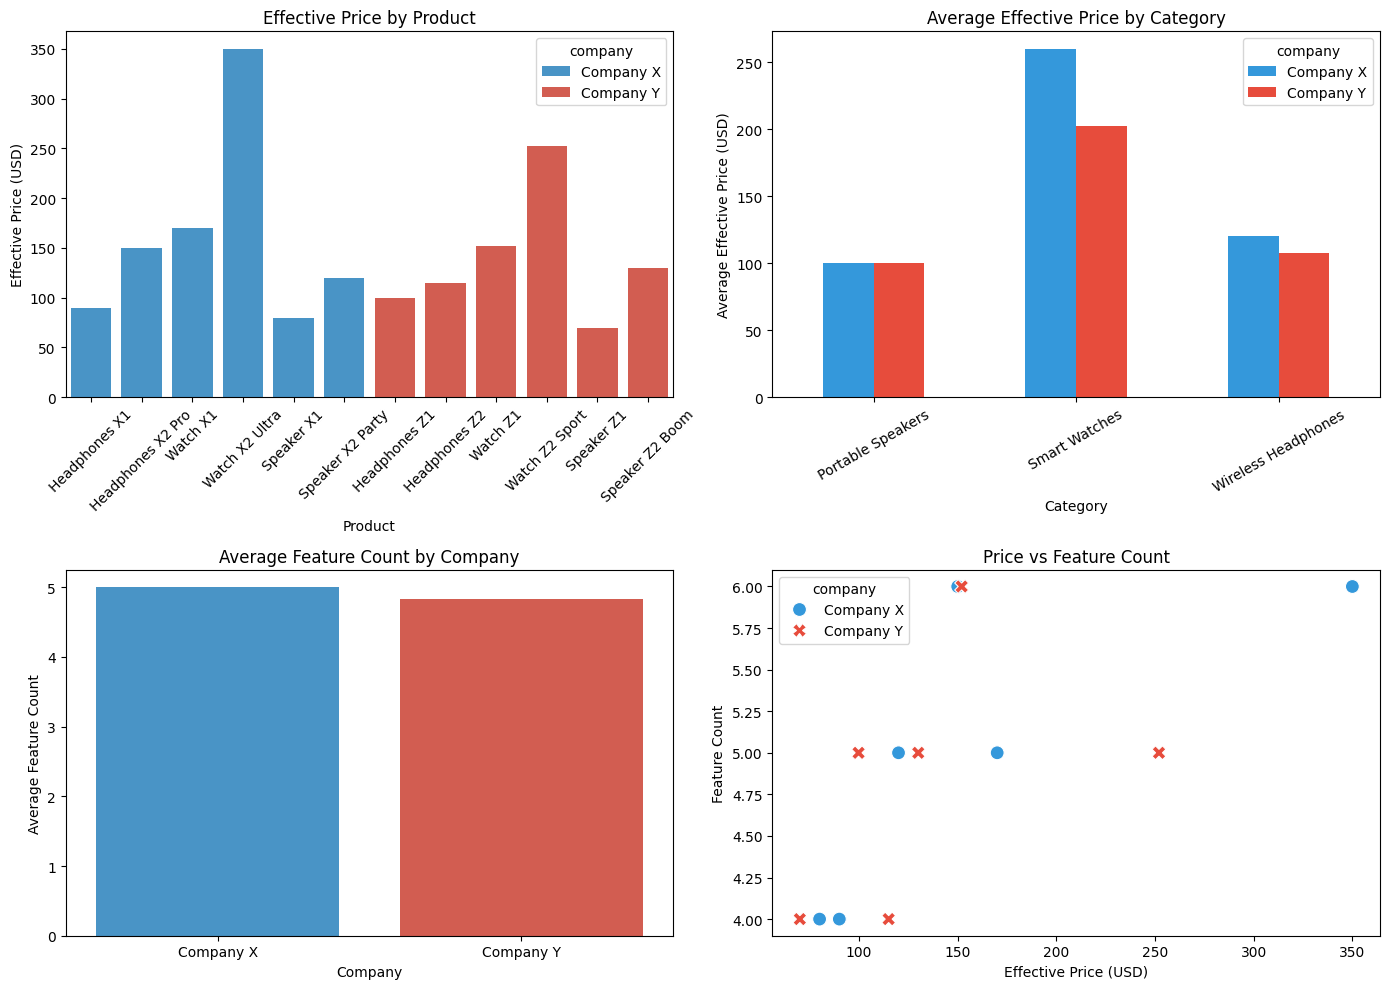

EDA visualization saved to ecommerce_eda.png


In [16]:
# ============================================================================
# TODO: EDA VISUALIZATION
# ============================================================================

# TODO: Create a 2x2 subplot figure showing:
# 1. Effective price comparison by product (bar chart)
# 2. Average price by category and company (grouped bar chart)
# 3. Average feature count by company (bar chart)
# 4. Scatter plot of price vs feature count, colored by company
#
# HINTS:
# - Use fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# - Company colors: {'Company X': '#3498db', 'Company Y': '#e74c3c'}
# - Save the figure as 'ecommerce_eda.png'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
company_colors = {'Company X': '#3498db', 'Company Y': '#e74c3c'}

# 1. Effective price comparison by product
sns.barplot(
    data=eda_df,
    x='product',
    y='effective_price',
    hue='company',
    palette=company_colors,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Effective Price by Product')
axes[0, 0].set_xlabel('Product')
axes[0, 0].set_ylabel('Effective Price (USD)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average price by category and company
avg_price_by_category = eda_df.pivot_table(
    index='category',
    columns='company',
    values='effective_price',
    aggfunc='mean'
)
avg_price_by_category.plot(
    kind='bar',
    color=[company_colors[company] for company in avg_price_by_category.columns],
    ax=axes[0, 1]
)
axes[0, 1].set_title('Average Effective Price by Category')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Average Effective Price (USD)')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Average feature count by company
avg_features_by_company = eda_df.groupby('company', as_index=False)['feature_count'].mean()
sns.barplot(
    data=avg_features_by_company,
    x='company',
    y='feature_count',
    hue='company',
    palette=company_colors,
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Average Feature Count by Company')
axes[1, 0].set_xlabel('Company')
axes[1, 0].set_ylabel('Average Feature Count')

# 4. Price vs feature count scatter plot
sns.scatterplot(
    data=eda_df,
    x='effective_price',
    y='feature_count',
    hue='company',
    style='company',
    palette=company_colors,
    s=100,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Price vs Feature Count')
axes[1, 1].set_xlabel('Effective Price (USD)')
axes[1, 1].set_ylabel('Feature Count')

plt.tight_layout()
plt.savefig('ecommerce_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA visualization saved to ecommerce_eda.png")

## Week 1 Checkpoint

Run this cell to verify your Week 1 implementation.

In [17]:
# ============================================================================
# WEEK 1 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 1 CHECKPOINT - Verification")
print("="*60)

checks = [
    ("IN_COLAB is defined", IN_COLAB is not None),
    ("Langfuse initialized", langfuse is not None),
    ("SESSION_ID created", SESSION_ID is not None and len(str(SESSION_ID)) > 0),
    ("OpenAI client ready", openai_client is not None),
    ("traced_embedding() implemented", traced_embedding is not None and traced_embedding.__code__.co_code != b'd\x00S\x00'),
    ("traced_completion() implemented", traced_completion is not None and traced_completion.__code__.co_code != b'd\x00S\x00'),
    ("get_langfuse_handler() implemented", get_langfuse_handler is not None),
    ("Company X catalog loaded", len(COMPANY_X_CATALOG['products']) == 6),
    ("Company Y catalog loaded", len(COMPANY_Y_CATALOG['products']) == 6),
    ("EDA DataFrame created", 'eda_df' in dir() and len(eda_df) == 12),
]

passed = 0
for check_name, check_result in checks:
    status = "PASS" if check_result else "FAIL"
    icon = "[OK]" if check_result else "[X]"
    print(f"  {icon} {check_name}: {status}")
    if check_result:
        passed += 1

print("\n" + "="*60)
print(f"Week 1 Score: {passed}/{len(checks)} checks passed")
if passed == len(checks):
    print("Week 1 Complete! Proceed to Week 2.")
else:
    print("Review failed checks before continuing.")

WEEK 1 CHECKPOINT - Verification
  [OK] IN_COLAB is defined: PASS
  [OK] Langfuse initialized: PASS
  [OK] SESSION_ID created: PASS
  [OK] OpenAI client ready: PASS
  [OK] traced_embedding() implemented: PASS
  [OK] traced_completion() implemented: PASS
  [OK] get_langfuse_handler() implemented: PASS
  [OK] Company X catalog loaded: PASS
  [OK] Company Y catalog loaded: PASS
  [OK] EDA DataFrame created: PASS

Week 1 Score: 10/10 checks passed
Week 1 Complete! Proceed to Week 2.


In [18]:

# ============================================================================
# PRODUCT CATALOG PROCESSOR CLASS
# ============================================================================

class TracedProductCatalogProcessor:
    """
    Process and normalize product catalogs with full Langfuse tracing.
    """

    def __init__(self):
        self.processed_products = []
        self.feature_vocabulary = set()

    def parse_discount(self, discount_str: str) -> Tuple[int, str]:
        """
        Parse discount string to extract percentage and type.

        Examples:
          "10% off"            -> (10, "percentage")
          "Free Shipping"      -> (0, "shipping")
          "5% off + Free Case" -> (5, "bundle")
        """
        if not discount_str:
            return (0, "none")

        pct_match = re.search(r'(\d+)%', discount_str)
        discount_pct = int(pct_match.group(1)) if pct_match else 0

        lower = discount_str.lower()

        if pct_match and ('free' in lower or '+' in lower):
            discount_type = "bundle"
        elif pct_match:
            discount_type = "percentage"
        elif 'shipping' in lower:
            discount_type = "shipping"
        elif 'free' in lower:
            discount_type = "free"
        else:
            discount_type = "other"

        return (discount_pct, discount_type)

    def normalize_features(self, features: List[str]) -> List[str]:
        """
        Normalize feature strings for comparison.
        Converts to lowercase and standardizes common abbreviations.
        Adds each normalized feature to self.feature_vocabulary.
        """
        abbreviation_map = {
            r'\banc\b': 'noise cancelling',
            r'\badvanced anc\b': 'advanced noise cancelling',
            r'\busb-c\b': 'usb-c charging',
            r'\bbt\b': 'bluetooth',
        }

        normalized = []
        for feature in features:
            norm = feature.lower().strip()
            for pattern, replacement in abbreviation_map.items():
                norm = re.sub(pattern, replacement, norm)
            self.feature_vocabulary.add(norm)
            normalized.append(norm)

        return normalized

    def normalize_product(self, product: Dict, company: str) -> Dict:
        """
        Return a fully normalized product dictionary.
        """
        discount_str = product.get('discount') or ''
        discount_pct, discount_type = self.parse_discount(discount_str)

        base_price = product['price']
        effective_price = round(base_price * (1 - discount_pct / 100), 2)

        features = product.get('features', [])
        features_normalized = self.normalize_features(features)
        feature_count = len(features)
        price_per_feature = round(effective_price / feature_count, 4) if feature_count > 0 else 0.0

        return {
            'company': company,
            'category': product.get('category', ''),
            'product_name': product.get('product_name', ''),
            'sku': product.get('sku', ''),
            'base_price': base_price,
            'discount_pct': discount_pct,
            'discount_type': discount_type,
            'effective_price': effective_price,
            'features': features,
            'features_normalized': features_normalized,
            'feature_count': feature_count,
            'availability': product.get('availability', ''),
            'discount_text': discount_str,
            'price_per_feature': price_per_feature,
        }

    def process_catalog(self, catalog: Dict) -> List[Dict]:
        """
        Process an entire catalog, normalizing all products and appending
        results to self.processed_products.
        """
        company = catalog.get('company', '')
        results = []
        for product in catalog.get('products', []):
            normalized = self.normalize_product(product, company)
            self.processed_products.append(normalized)
            results.append(normalized)
        return results

    def process_catalog_with_tracing(self, catalog: Dict) -> List[Dict]:
        """
        Process entire catalog with Langfuse tracing.

        Creates a top-level Langfuse trace for the full catalog run, then
        creates a child span per product. Appends normalized products (with
        a unique product_id) to self.processed_products and returns them.
        """
        company = catalog.get('company', '')
        products = catalog.get('products', [])

        trace = langfuse.trace(
            name=f"catalog-processing-{company}",
            session_id=SESSION_ID,
            tags=['catalog-processing', 'week-2'],
            metadata={
                'company': company,
                'product_count': len(products),
            }
        )

        results = []
        for index, product in enumerate(products):
            product_id = f"{company.replace(' ', '')}_{index:03d}"

            span = trace.span(
                name=f"normalize-product-{product_id}",
                input={
                    'product_name': product.get('product_name'),
                    'sku': product.get('sku'),
                }
            )

            normalized = self.normalize_product(product, company)
            normalized['product_id'] = product_id

            span.end(output={
                'product_id': product_id,
                'effective_price': normalized['effective_price'],
                'feature_count': normalized['feature_count'],
                'discount_type': normalized['discount_type'],
            })

            self.processed_products.append(normalized)
            results.append(normalized)

        trace.update(
            output={
                'processed_count': len(results),
                'avg_price': round(
                    sum(p['effective_price'] for p in results) / len(results), 2
                ) if results else 0,
                'avg_features': round(
                    sum(p['feature_count'] for p in results) / len(results), 2
                ) if results else 0,
                'discounted_count': sum(
                    1 for p in results if p['discount_pct'] > 0
                ),
            }
        )

        return results

    def compare_products(self, product_x: Dict, product_y: Dict) -> Dict:
        """
        Compare two products head-to-head.

        Returns a comparison dict with pricing, feature, and value analysis.
        """
        price_x = product_x['effective_price']
        price_y = product_y['effective_price']
        price_diff = round(price_x - price_y, 2)
        price_diff_pct = round((price_diff / price_y) * 100, 2) if price_y else 0.0

        if price_x < price_y:
            price_advantage = 'X'
        elif price_y < price_x:
            price_advantage = 'Y'
        else:
            price_advantage = 'tie'

        features_x = set(f.lower() for f in product_x.get('features_normalized', product_x.get('features', [])))
        features_y = set(f.lower() for f in product_y.get('features_normalized', product_y.get('features', [])))

        feature_count_x = product_x['feature_count']
        feature_count_y = product_y['feature_count']

        if feature_count_x > feature_count_y:
            feature_advantage = 'X'
        elif feature_count_y > feature_count_x:
            feature_advantage = 'Y'
        else:
            feature_advantage = 'tie'

        value_x = round((feature_count_x / price_x) * 100, 4) if price_x else 0.0
        value_y = round((feature_count_y / price_y) * 100, 4) if price_y else 0.0

        if value_x > value_y:
            value_advantage = 'X'
        elif value_y > value_x:
            value_advantage = 'Y'
        else:
            value_advantage = 'tie'

        return {
            'category': product_x.get('category', ''),
            'product_x': product_x.get('product_name', ''),
            'product_y': product_y.get('product_name', ''),
            'price_x': price_x,
            'price_y': price_y,
            'price_diff': price_diff,
            'price_diff_pct': price_diff_pct,
            'price_advantage': price_advantage,
            'features_x': feature_count_x,
            'features_y': feature_count_y,
            'feature_advantage': feature_advantage,
            'value_x': value_x,
            'value_y': value_y,
            'value_advantage': value_advantage,
            'unique_to_x': sorted(features_x - features_y),
            'unique_to_y': sorted(features_y - features_x),
            'common_features': sorted(features_x & features_y),
        }


print("TracedProductCatalogProcessor class defined successfully")


TracedProductCatalogProcessor class defined successfully


In [19]:

# ============================================================================
# PROCESS BOTH CATALOGS
# ============================================================================

# Initialize processor
processor = TracedProductCatalogProcessor()

# Process both catalogs with Langfuse tracing
products_x = processor.process_catalog_with_tracing(COMPANY_X_CATALOG)
products_y = processor.process_catalog_with_tracing(COMPANY_Y_CATALOG)

# Combine all products
all_products = products_x + products_y

print(f"\nProcessing Complete:")
print(f"  Company X: {len(products_x)} products")
print(f"  Company Y: {len(products_y)} products")
print(f"  Total: {len(all_products)} products")
print(f"  Feature Vocabulary: {len(processor.feature_vocabulary)} unique features")

# ============================================================================
# RUN PRODUCT COMPARISONS
# ============================================================================

print("\nPRODUCT COMPARISONS")
print("="*60)

categories = ["Wireless Headphones", "Smart Watches", "Portable Speakers"]

for category in categories:
    # Get first product from each company in this category
    cat_x = [p for p in products_x if p['category'] == category]
    cat_y = [p for p in products_y if p['category'] == category]

    if not cat_x or not cat_y:
        continue

    comp = processor.compare_products(cat_x[0], cat_y[0])

    print(f"\n[{comp['category']}]")
    print(f"  {comp['product_x']} vs {comp['product_y']}")
    print(f"  Price: ${comp['price_x']} vs ${comp['price_y']} -> Advantage: {comp['price_advantage']}")
    print(f"  Features: {comp['features_x']} vs {comp['features_y']} -> Advantage: {comp['feature_advantage']}")
    print(f"  Value Score: {comp['value_x']} vs {comp['value_y']} -> Advantage: {comp['value_advantage']}")
    if comp['unique_to_x']:
        print(f"  Unique to X: {', '.join(comp['unique_to_x'])}")
    if comp['unique_to_y']:
        print(f"  Unique to Y: {', '.join(comp['unique_to_y'])}")
    if comp['common_features']:
        print(f"  Common: {', '.join(comp['common_features'])}")



Processing Complete:
  Company X: 6 products
  Company Y: 6 products
  Total: 12 products
  Feature Vocabulary: 35 unique features

PRODUCT COMPARISONS

[Wireless Headphones]
  Headphones X1 vs Headphones Z1
  Price: $89.99 vs $99.75 -> Advantage: X
  Features: 4 vs 5 -> Advantage: Y
  Value Score: 4.4449 vs 5.0125 -> Advantage: Y
  Unique to X: 20h battery, bluetooth 5.0
  Unique to Y: 25h battery, bluetooth 5.2, quick charge
  Common: foldable, noise cancelling

[Smart Watches]
  Watch X1 vs Watch Z1
  Price: $169.99 vs $151.99 -> Advantage: Y
  Features: 5 vs 6 -> Advantage: Y
  Value Score: 2.9413 vs 3.9476 -> Advantage: Y
  Unique to X: 5 day battery
  Unique to Y: 7 day battery, spo2
  Common: gps, heart rate, sleep tracking, water resistant

[Portable Speakers]
  Speaker X1 vs Speaker Z1
  Price: $79.99 vs $69.99 -> Advantage: Y
  Features: 4 vs 4 -> Advantage: tie
  Value Score: 5.0006 vs 5.7151 -> Advantage: Y
  Unique to X: 12h battery, 360 sound
  Unique to Y: 15h battery, 

In [20]:
# ============================================================================
# WEEK 2 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 2 CHECKPOINT - Verification")
print("="*60)

checks = [
    ("Processor initialized", processor is not None),
    ("parse_discount() works", processor.parse_discount("10% off")[0] == 10),
    ("normalize_features() works", len(processor.normalize_features(["Test"])) == 1),
    ("products_x processed", len(products_x) == 6),
    ("products_y processed", len(products_y) == 6),
    ("Products have product_id", all('product_id' in p for p in all_products)),
    ("Products have effective_price", all('effective_price' in p for p in all_products)),
    ("Feature vocabulary populated", len(processor.feature_vocabulary) > 10),
]

passed = 0
for check_name, check_result in checks:
    try:
        result = bool(check_result)
    except:
        result = False
    status = "PASS" if result else "FAIL"
    icon = "[OK]" if result else "[X]"
    print(f"  {icon} {check_name}: {status}")
    if result:
        passed += 1

print("\n" + "="*60)
print(f"Week 2 Score: {passed}/{len(checks)} checks passed")
if passed == len(checks):
    print("Week 2 Complete! Proceed to Week 3.")
else:
    print("Review failed checks before continuing.")

WEEK 2 CHECKPOINT - Verification
  [OK] Processor initialized: PASS
  [OK] parse_discount() works: PASS
  [OK] normalize_features() works: PASS
  [OK] products_x processed: PASS
  [OK] products_y processed: PASS
  [OK] Products have product_id: PASS
  [OK] Products have effective_price: PASS
  [OK] Feature vocabulary populated: PASS

Week 2 Score: 8/8 checks passed
Week 2 Complete! Proceed to Week 3.


In [21]:

# ============================================================================
# PRODUCT VECTOR STORE CLASS
# ============================================================================

import chromadb
from chromadb.config import Settings

class TracedProductVectorStore:
    """
    Vector store for semantic product search with full Langfuse tracing.

    Uses ChromaDB for in-memory vector storage and OpenAI text-embedding-3-small
    for generating embeddings. Every indexing and search operation is traced
    via Langfuse for full observability.
    """

    def __init__(self):
        # In-memory ChromaDB client with telemetry disabled to suppress
        # PostHog API mismatch errors in chromadb 0.5.23
        self.client = chromadb.Client(Settings(anonymized_telemetry=False))
        # Registry of named collections: { collection_name -> ChromaDB collection }
        self.collections = {}

    # ------------------------------------------------------------------
    # Text Representation
    # ------------------------------------------------------------------

    def create_product_text(self, product: Dict) -> str:
        """
        Build a plain-text description of a product suitable for embedding.

        Combines the most semantically meaningful fields so that similar
        products will cluster together in vector space.

        Example output:
          "Headphones X1. Category: Wireless Headphones. Price: $89.99.
           Features: Bluetooth 5.0, Noise Cancelling, 20h Battery, Foldable."
        """
        product_name = product.get('product_name', '')
        category     = product.get('category', '')
        price        = product.get('effective_price', product.get('base_price', 0))
        features     = product.get('features', [])
        company      = product.get('company', '')

        features_str = ', '.join(features) if features else 'None'

        return (
            f"{product_name}. "
            f"Company: {company}. "
            f"Category: {category}. "
            f"Price: ${price}. "
            f"Features: {features_str}."
        )

    # ------------------------------------------------------------------
    # Indexing
    # ------------------------------------------------------------------

    def index_products_with_tracing(
        self,
        products: List[Dict],
        collection_name: str = "products"
    ) -> None:
        """
        Embed and store all products in a ChromaDB collection.

        Steps:
          1. Create (or reuse) a named ChromaDB collection.
          2. Open a Langfuse trace for the full indexing run.
          3. For each product:
             a. Build a text description.
             b. Generate an embedding via traced_embedding().
             c. Accumulate ids / embeddings / documents / metadata.
          4. Bulk-add everything to ChromaDB in one call.
          5. Update the Langfuse trace with a summary.
        """
        # Create or retrieve the collection
        collection = self.client.get_or_create_collection(collection_name)
        self.collections[collection_name] = collection

        # Top-level Langfuse trace for the entire indexing job
        trace = langfuse.trace(
            name=f"vector-store-indexing-{collection_name}",
            session_id=SESSION_ID,
            tags=['vector-store', 'indexing', 'week-3'],
            metadata={
                'collection': collection_name,
                'product_count': len(products),
            }
        )

        # Accumulate batch data to add in one shot
        ids        = []
        embeddings = []
        documents  = []
        metadatas  = []

        for product in products:
            # Use product_id if available, otherwise fall back to SKU
            doc_id = product.get('product_id') or product.get('sku', '')

            # Build the human-readable text that will be embedded
            text = self.create_product_text(product)

            # Generate embedding with its own child trace span
            embedding = traced_embedding(
                text,
                trace_name=f"embed-{doc_id}"
            )

            # Metadata stored alongside the vector for post-retrieval filtering
            metadata = {
                'product_id':   doc_id,
                'product_name': product.get('product_name', ''),
                'company':      product.get('company', ''),
                'category':     product.get('category', ''),
                'price':        str(product.get('effective_price', 0)),
                'availability': product.get('availability', ''),
                'sku':          product.get('sku', ''),
            }

            ids.append(doc_id)
            embeddings.append(embedding)
            documents.append(text)
            metadatas.append(metadata)

        # Bulk insert into ChromaDB
        collection.add(
            ids=ids,
            embeddings=embeddings,
            documents=documents,
            metadatas=metadatas
        )

        # Record summary on the trace
        trace.update(
            output={
                'indexed_count': len(ids),
                'collection': collection_name,
            }
        )

        print(f"Indexed {len(ids)} products to '{collection_name}' collection")

    # ------------------------------------------------------------------
    # Semantic Search
    # ------------------------------------------------------------------

    def search_with_tracing(
        self,
        query: str,
        collection_name: str = "products",
        n_results: int = 5
    ) -> Dict:
        """
        Run a semantic similarity search against a named collection.

        Steps:
          1. Create a Langfuse trace for this search.
          2. Embed the query string using traced_embedding().
          3. Query ChromaDB for the top-n nearest neighbours.
          4. Log the result summary to the trace and return raw results.

        Returns the ChromaDB query result dict which contains:
          - 'documents'  : list of matching product text descriptions
          - 'metadatas'  : list of metadata dicts (name, company, price, …)
          - 'distances'  : cosine distances (lower = more similar)
          - 'ids'        : list of document ids
        """
        # Ensure the requested collection exists
        if collection_name not in self.collections:
            raise ValueError(
                f"Collection '{collection_name}' not found. "
                "Run index_products_with_tracing() first."
            )

        collection = self.collections[collection_name]

        # Top-level trace for this search request
        trace = langfuse.trace(
            name="vector-store-search",
            session_id=SESSION_ID,
            tags=['vector-store', 'search', 'week-3'],
            metadata={
                'query': query,
                'collection': collection_name,
                'n_results': n_results,
            }
        )

        # Embed the query text (this call creates its own child trace)
        query_embedding = traced_embedding(query, trace_name="embed-query")

        # Perform the nearest-neighbour search in ChromaDB
        results = collection.query(
            query_embeddings=[query_embedding],
            n_results=n_results,
            include=['documents', 'metadatas', 'distances']
        )

        # Log result summary back to the trace
        top_results = []
        if results.get('metadatas') and results['metadatas'][0]:
            top_results = [
                {
                    'product_name': m.get('product_name'),
                    'company':      m.get('company'),
                    'distance':     round(d, 4),
                }
                for m, d in zip(
                    results['metadatas'][0],
                    results['distances'][0]
                )
            ]

        trace.update(output={'top_results': top_results})

        return results


# ------------------------------------------------------------------
# INDEX ALL PRODUCTS
# ------------------------------------------------------------------

# Create a fresh vector store instance
product_vector_store = TracedProductVectorStore()

# Embed and index every product from both catalogs
product_vector_store.index_products_with_tracing(all_products, "products")

print("Product indexing complete")


Indexed 12 products to 'products' collection
Product indexing complete


In [22]:

# ============================================================================
# SEMANTIC SEARCH EXAMPLES
# ============================================================================

print("SEMANTIC SEARCH EXAMPLES")
print("="*60)

# A variety of natural-language queries that test semantic understanding —
# none of these match product names or features exactly, so they exercise
# the embedding model's ability to bridge vocabulary gaps.
test_queries = [
    "headphones with long battery life and noise cancellation",
    "waterproof speaker for outdoor parties",
    "fitness watch with heart rate monitoring",
    "affordable wireless earbuds",
    "premium smartwatch with GPS"
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    print("-" * 50)

    # Run semantic search — returns top 3 most similar products
    results = product_vector_store.search_with_tracing(query, n_results=3)

    # Unpack the ChromaDB result structure:
    #   results['metadatas'][0]  -> list of metadata dicts for each hit
    #   results['distances'][0]  -> corresponding cosine distances (lower = closer)
    metadatas = results.get('metadatas', [[]])[0]
    distances = results.get('distances', [[]])[0]

    for rank, (meta, dist) in enumerate(zip(metadatas, distances), start=1):
        # Convert cosine distance to a 0-1 similarity score
        similarity = round(1 - dist, 4)
        print(
            f"  {rank}. {meta.get('product_name')} ({meta.get('company')}) "
            f"- ${meta.get('price')} "
            f"[similarity: {similarity}]"
        )


# ============================================================================
# WEEK 3 CHECKPOINT - VALIDATION
# ============================================================================

print("\nWEEK 3 CHECKPOINT - Verification")
print("="*60)

checks = [
    ("Vector store initialized",        product_vector_store is not None),
    ("ChromaDB client created",          product_vector_store.client is not None),
    ("Products collection exists",       'products' in product_vector_store.collections),
    ("create_product_text() works",      product_vector_store.create_product_text(all_products[0]) is not None),
    ("Search returns results",           product_vector_store.search_with_tracing("headphones", n_results=3) is not None),
]

passed = 0
for check_name, check_result in checks:
    try:
        result = bool(check_result)
    except Exception:
        result = False
    status = "PASS" if result else "FAIL"
    icon   = "[OK]"  if result else "[X]"
    print(f"  {icon} {check_name}: {status}")
    if result:
        passed += 1

print("\n" + "="*60)
print(f"Week 3 Score: {passed}/{len(checks)} checks passed")
if passed == len(checks):
    print("Week 3 Complete! Proceed to Week 4.")
else:
    print("Review failed checks before continuing.")


SEMANTIC SEARCH EXAMPLES

Query: 'headphones with long battery life and noise cancellation'
--------------------------------------------------
  1. Headphones Z2 (Company Y) - $115.0 [similarity: 0.1394]
  2. Headphones Z1 (Company Y) - $99.75 [similarity: 0.1282]
  3. Headphones X2 Pro (Company X) - $149.99 [similarity: 0.1163]

Query: 'waterproof speaker for outdoor parties'
--------------------------------------------------
  1. Speaker X2 Party (Company X) - $119.99 [similarity: 0.1777]
  2. Speaker X1 (Company X) - $79.99 [similarity: 0.1079]
  3. Speaker Z1 (Company Y) - $69.99 [similarity: 0.0951]

Query: 'fitness watch with heart rate monitoring'
--------------------------------------------------
  1. Watch Z1 (Company Y) - $151.99 [similarity: 0.1488]
  2. Watch Z2 Sport (Company Y) - $251.99 [similarity: 0.0983]
  3. Watch X1 (Company X) - $169.99 [similarity: 0.0727]

Query: 'affordable wireless earbuds'
--------------------------------------------------
  1. Headphones Z1 (

In [23]:

# ============================================================================
# PYDANTIC MODELS FOR STRUCTURED OUTPUTS
# ============================================================================

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

# ============================================================================
# PRICE ANALYSIS MODEL
# Captures the result of comparing our pricing against a competitor's
# within a single product category.
# ============================================================================

class PriceAnalysis(BaseModel):
    """Structured output for price analysis."""

    # The product category being analyzed (e.g. "Wireless Headphones")
    category: str = Field(description="Product category analyzed")

    # Average effective price (after discounts) across our products in this category
    our_avg_price: float = Field(description="Our average effective price in USD")

    # Average effective price across the competitor's products in this category
    competitor_avg_price: float = Field(description="Competitor average effective price in USD")

    # Relative pricing position:
    #   PREMIUM      -> we are priced higher than the competitor
    #   COMPETITIVE  -> prices are roughly equal
    #   VALUE        -> we are priced lower than the competitor
    price_position: str = Field(
        description="Pricing position relative to competitor: PREMIUM, COMPETITIVE, or VALUE"
    )

    # (our_avg_price - competitor_avg_price) / competitor_avg_price * 100
    price_gap_pct: float = Field(
        description="Price gap as a percentage: positive means we are more expensive"
    )

    # Actionable pricing recommendations derived from the analysis
    recommendations: List[str] = Field(
        description="List of actionable pricing recommendations"
    )

    # Model confidence in the analysis (0 = no confidence, 1 = fully confident)
    confidence: float = Field(
        ge=0.0, le=1.0,
        description="Confidence score for the analysis, between 0.0 and 1.0"
    )


print("PriceAnalysis model defined successfully")


# ============================================================================
# FEATURE ANALYSIS MODEL
# Captures the result of comparing product features between the two companies
# in a single category, highlighting gaps and competitive advantages.
# ============================================================================

class FeatureAnalysis(BaseModel):
    """Structured output for feature / catalog analysis."""

    # The product category being analyzed
    category: str = Field(description="Product category analyzed")

    # Features that appear in our products but not in the competitor's
    our_strengths: List[str] = Field(
        description="Features unique to our products (our differentiators)"
    )

    # Features that appear in the competitor's products but not in ours
    competitor_strengths: List[str] = Field(
        description="Features unique to the competitor's products"
    )

    # Features the competitor offers that we currently lack and should consider adding
    feature_gaps: List[str] = Field(
        description="Features we are missing that the competitor offers"
    )

    # A concise statement of our primary competitive advantage in this category
    competitive_advantage: str = Field(
        description="Our main competitive advantage in this category"
    )

    # Recommended product development actions based on the gap analysis
    recommendations: List[str] = Field(
        description="Product development recommendations to close feature gaps"
    )

    # Model confidence in the analysis
    confidence: float = Field(
        ge=0.0, le=1.0,
        description="Confidence score for the analysis, between 0.0 and 1.0"
    )


print("FeatureAnalysis model defined successfully")


# ============================================================================
# MARKETING CONTENT MODEL
# Structured output for AI-generated marketing copy for a single product,
# informed by competitive intelligence data.
# ============================================================================

class MarketingContent(BaseModel):
    """Structured output for marketing content generation."""

    # The product this content is written for
    product_name: str = Field(description="Name of the product being marketed")

    # Short, attention-grabbing marketing headline (one sentence)
    headline: str = Field(
        description="Attention-grabbing marketing headline for the product"
    )

    # Top 3-5 customer-facing benefits to feature in marketing materials
    key_benefits: List[str] = Field(
        description="Top benefits to highlight in marketing copy"
    )

    # Factually defensible comparative claims vs competitors
    competitive_claims: List[str] = Field(
        description="Defensible comparative claims against competitor products"
    )

    # Primary customer segment this content is aimed at
    target_audience: str = Field(
        description="Target customer segment for this product"
    )

    # Clear call-to-action phrase for ads, landing pages, or emails
    call_to_action: str = Field(
        description="Compelling call-to-action text"
    )

    # Model confidence in the generated content
    confidence: float = Field(
        ge=0.0, le=1.0,
        description="Confidence score for the generated content, between 0.0 and 1.0"
    )


print("MarketingContent model defined successfully")


PriceAnalysis model defined successfully
FeatureAnalysis model defined successfully
MarketingContent model defined successfully


In [24]:
# ============================================================================
# PRICE MONITOR AGENT
# ============================================================================

class TracedPriceMonitorAgent:
    """
    Price Monitor Agent with full Langfuse tracing.

    Uses an LLM to analyze competitor pricing data for a given category and
    returns a structured PriceAnalysis output. Every invocation is traced
    via a Langfuse callback handler attached to the LangChain chain.
    """

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model = model

        # Parser tells the LLM exactly what JSON schema to produce
        self.parser = PydanticOutputParser(pydantic_object=PriceAnalysis)

        # System message sets the agent's role and reasoning guidelines.
        # {format_instructions} is injected at runtime by the parser.
        system_message = """\
You are a competitive pricing intelligence analyst.
Your job is to compare our product pricing against a competitor's within a single category.

Pricing position rules:
  - PREMIUM     : our average price is more than 10% higher than the competitor
  - COMPETITIVE : our average price is within +/-10% of the competitor
  - VALUE       : our average price is more than 10% lower than the competitor

Consider price elasticity, value perception, and discount strategies.
Provide concrete, actionable pricing recommendations.

{format_instructions}"""

        self.prompt = ChatPromptTemplate.from_messages([
            ("system", system_message),
            ("human",
             "Category: {category}\n\nProduct pricing data:\n{product_data}\n\n"
             "Analyze the pricing and return a structured PriceAnalysis."),
        ])

    def analyze(self, product_data: str, category: str = "unknown") -> Dict:
        """
        Run a price analysis for the given category and product data.

        Args:
            product_data: Formatted string describing our and competitor products.
            category:     The product category being analyzed.

        Returns:
            Dict with keys:
              'success' (bool)
              'result'  (PriceAnalysis as dict) on success
              'error'   (str) on failure
        """
        try:
            # Attach a Langfuse callback handler so the full chain is traced
            handler = get_langfuse_handler(
                trace_name=f"price-agent-{category}",
                tags=["price-agent", "week-4"]
            )

            # Build LLM with the callback attached
            llm = ChatOpenAI(
                model=self.model,
                temperature=0,
                openai_api_key=os.environ["OPENAI_API_KEY"],
                callbacks=[handler]
            )

            # Assemble and invoke the chain: prompt -> LLM -> structured parser
            chain = self.prompt | llm | self.parser

            result: PriceAnalysis = chain.invoke({
                "category": category,
                "product_data": product_data,
                "format_instructions": self.parser.get_format_instructions(),
            })

            return {"success": True, "result": result.model_dump()}

        except Exception as e:
            return {"success": False, "error": str(e)}


# Initialize agent
price_agent = TracedPriceMonitorAgent()
print("TracedPriceMonitorAgent defined successfully")


TracedPriceMonitorAgent defined successfully


In [25]:
# ============================================================================
# CATALOG ANALYZER AGENT
# ============================================================================

class TracedCatalogAnalyzerAgent:
    """
    Catalog Analyzer Agent with full Langfuse tracing.

    Uses an LLM to compare product features between our catalog and a
    competitor's for a given category and returns a structured FeatureAnalysis.
    """

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model = model

        # Parser enforces the FeatureAnalysis JSON schema
        self.parser = PydanticOutputParser(pydantic_object=FeatureAnalysis)

        system_message = """\
You are a product catalog competitive intelligence analyst.
Your job is to compare product features between our catalog and a competitor's
within a single product category.

Your analysis should:
  - Identify products that are missing in our catalog but present in the competitor's and vice versa
  - Identify gaps in our product lineup in the category compared to competitor that we should consider filling
  - Identify features that are unique to our products (our differentiators)
  - Identify features that are unique to the competitor (their differentiators)
  - Highlight feature gaps we should consider closing
  - Determine our primary competitive advantage
  - Provide actionable product development recommendations, pricing opportunities, or marketing angles based on the analysis

{format_instructions}"""

        self.prompt = ChatPromptTemplate.from_messages([
            ("system", system_message),
            ("human",
             "Category: {category}\n\nProduct feature data:\n{product_data}\n\n"
             "Analyze the feature landscape and return a structured FeatureAnalysis."),
        ])

    def analyze(self, product_data: str, category: str = "unknown") -> Dict:
        """
        Run a feature / catalog analysis for the given category.

        Args:
            product_data: Formatted string describing our and competitor products.
            category:     The product category being analyzed.

        Returns:
            Dict with 'success' (bool) and 'result' (FeatureAnalysis as dict)
            or 'error' (str) on failure.
        """
        try:
            handler = get_langfuse_handler(
                trace_name=f"catalog-agent-{category}",
                tags=["catalog-agent", "week-4"]
            )

            llm = ChatOpenAI(
                model=self.model,
                temperature=0,
                openai_api_key=os.environ["OPENAI_API_KEY"],
                callbacks=[handler]
            )

            chain = self.prompt | llm | self.parser

            result: FeatureAnalysis = chain.invoke({
                "category": category,
                "product_data": product_data,
                "format_instructions": self.parser.get_format_instructions(),
            })

            return {"success": True, "result": result.model_dump()}

        except Exception as e:
            return {"success": False, "error": str(e)}


catalog_agent = TracedCatalogAnalyzerAgent()
print("TracedCatalogAnalyzerAgent defined successfully")


TracedCatalogAnalyzerAgent defined successfully


In [26]:
# ============================================================================
# MARKETING AGENT
# ============================================================================

class TracedMarketingAgent:
    """
    Marketing Agent with full Langfuse tracing.

    Uses an LLM to generate competitive marketing copy for a specific product,
    informed by both our product data and the competitor's. Returns a structured
    MarketingContent output. Temperature is set to 0.7 for creative variety.
    """

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model = model

        # Parser enforces the MarketingContent JSON schema
        self.parser = PydanticOutputParser(pydantic_object=MarketingContent)

        system_message = """\
You are an expert marketing copywriter specialising in consumer electronics.
Your job is to create compelling, competitive marketing content for a specific product.

Guidelines:
  - Lead with customer benefits, not just technical features
  - Write an attention-grabbing headline that differentiates us from competitors
  - Make only credible, factually defensible comparative claims
  - Use engaging, action-oriented language throughout
  - Identify the most relevant target customer segment
  - End with a clear, compelling call-to-action

{format_instructions}"""

        self.prompt = ChatPromptTemplate.from_messages([
            ("system", system_message),
            ("human",
             "Product to market: {product_name}\n\n"
             "Our product details:\n{product_data}\n\n"
             "Competitor product details:\n{competitor_data}\n\n"
             "Generate compelling marketing content and return a structured MarketingContent."),
        ])

    def generate(
        self,
        product_data: str,
        competitor_data: str,
        product_name: str = "product"
    ) -> Dict:
        """
        Generate marketing content for a product given competitive context.

        Args:
            product_data:    Formatted description of our product.
            competitor_data: Formatted description of competing products.
            product_name:    Name of the product being marketed.

        Returns:
            Dict with 'success' (bool) and 'result' (MarketingContent as dict)
            or 'error' (str) on failure.
        """
        try:
            handler = get_langfuse_handler(
                trace_name=f"marketing-agent-{product_name}",
                tags=["marketing-agent", "week-4"]
            )

            # Higher temperature for more creative, varied marketing copy
            llm = ChatOpenAI(
                model=self.model,
                temperature=0.7,
                openai_api_key=os.environ["OPENAI_API_KEY"],
                callbacks=[handler]
            )

            chain = self.prompt | llm | self.parser

            result: MarketingContent = chain.invoke({
                "product_name": product_name,
                "product_data": product_data,
                "competitor_data": competitor_data,
                "format_instructions": self.parser.get_format_instructions(),
            })

            return {"success": True, "result": result.model_dump()}

        except Exception as e:
            return {"success": False, "error": str(e)}


marketing_agent = TracedMarketingAgent()
print("TracedMarketingAgent defined successfully")


TracedMarketingAgent defined successfully


In [27]:
# ============================================================================
# TEST ALL AGENTS
# ============================================================================

print("AGENT TESTING")
print("="*60)

# Prepare test data for one category
category = "Wireless Headphones"
x_prods = [p for p in products_x if p['category'] == category]
y_prods = [p for p in products_y if p['category'] == category]

data_text = "Our Products (Company X):\n"
for p in x_prods:
    data_text += f"- {p['product_name']}: ${p['effective_price']}, Features: {', '.join(p['features'])}\n"
data_text += "\nCompetitor Products (Company Y):\n"
for p in y_prods:
    data_text += f"- {p['product_name']}: ${p['effective_price']}, Features: {', '.join(p['features'])}\n"

print(f"\nTest data prepared for category: {category}")
print(data_text)

# -----------------------------------------------------------------------
# Test Price Agent
# -----------------------------------------------------------------------
print("\n[Price Agent]")
print("-" * 40)
price_result = price_agent.analyze(data_text, category)
if price_result['success']:
    r = price_result['result']
    print(f"  Category:        {r['category']}")
    print(f"  Our avg price:   ${r['our_avg_price']}")
    print(f"  Comp avg price:  ${r['competitor_avg_price']}")
    print(f"  Position:        {r['price_position']}")
    print(f"  Price gap:       {r['price_gap_pct']}%")
    print(f"  Confidence:      {r['confidence']}")
    print(f"  Recommendations:")
    for rec in r['recommendations']:
        print(f"    - {rec}")
else:
    print(f"  ERROR: {price_result['error']}")

# -----------------------------------------------------------------------
# Test Catalog Agent
# -----------------------------------------------------------------------
print("\n[Catalog Agent]")
print("-" * 40)
catalog_result = catalog_agent.analyze(data_text, category)
if catalog_result['success']:
    r = catalog_result['result']
    print(f"  Category:             {r['category']}")
    print(f"  Our strengths:        {r['our_strengths']}")
    print(f"  Competitor strengths: {r['competitor_strengths']}")
    print(f"  Feature gaps:         {r['feature_gaps']}")
    print(f"  Competitive advantage: {r['competitive_advantage']}")
    print(f"  Confidence:           {r['confidence']}")
    print(f"  Recommendations:")
    for rec in r['recommendations']:
        print(f"    - {rec}")
else:
    print(f"  ERROR: {catalog_result['error']}")

# -----------------------------------------------------------------------
# Test Marketing Agent
# -----------------------------------------------------------------------
print("\n[Marketing Agent]")
print("-" * 40)
product = x_prods[0]
competitor = y_prods[0]

product_data_text = (
    f"{product['product_name']}: ${product['effective_price']}, "
    f"Features: {', '.join(product['features'])}"
)
competitor_data_text = (
    f"{competitor['product_name']}: ${competitor['effective_price']}, "
    f"Features: {', '.join(competitor['features'])}"
)

marketing_result = marketing_agent.generate(
    product_data=product_data_text,
    competitor_data=competitor_data_text,
    product_name=product['product_name']
)
if marketing_result['success']:
    r = marketing_result['result']
    print(f"  Product:          {r['product_name']}")
    print(f"  Headline:         {r['headline']}")
    print(f"  Target audience:  {r['target_audience']}")
    print(f"  Call to action:   {r['call_to_action']}")
    print(f"  Key benefits:")
    for b in r['key_benefits']:
        print(f"    - {b}")
    print(f"  Competitive claims:")
    for c in r['competitive_claims']:
        print(f"    - {c}")
    print(f"  Confidence:       {r['confidence']}")
else:
    print(f"  ERROR: {marketing_result['error']}")


AGENT TESTING

Test data prepared for category: Wireless Headphones
Our Products (Company X):
- Headphones X1: $89.99, Features: Bluetooth 5.0, Noise Cancelling, 20h Battery, Foldable
- Headphones X2 Pro: $149.99, Features: Bluetooth 5.2, Advanced ANC, 30h Battery, Foldable, USB-C, Multipoint

Competitor Products (Company Y):
- Headphones Z1: $99.75, Features: Bluetooth 5.2, Noise Cancelling, 25h Battery, Quick Charge, Foldable
- Headphones Z2: $115.0, Features: Bluetooth 5.2, Advanced Noise Cancelling, 30h Battery, Waterproof


[Price Agent]
----------------------------------------
  Category:        Wireless Headphones
  Our avg price:   $119.99
  Comp avg price:  $107.875
  Position:        PREMIUM
  Price gap:       11.5%
  Confidence:      0.85
  Recommendations:
    - Consider reducing the price of Headphones X1 to be more competitive with Headphones Z1.
    - Evaluate the features of Headphones X2 Pro to justify the premium pricing or consider a promotional discount.
    - Imple

In [28]:
# ============================================================================
# WEEK 4 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 4 CHECKPOINT - Verification")
print("="*60)

checks = [
    ("PriceAnalysis model defined", 'PriceAnalysis' in dir()),
    ("FeatureAnalysis model defined", 'FeatureAnalysis' in dir()),
    ("MarketingContent model defined", 'MarketingContent' in dir()),
    ("Price agent initialized", price_agent is not None),
    ("Catalog agent initialized", catalog_agent is not None),
    ("Marketing agent initialized", marketing_agent is not None),
    ("Price agent has analyze method", hasattr(price_agent, 'analyze')),
    ("Marketing agent has generate method", hasattr(marketing_agent, 'generate')),
]

passed = 0
for check_name, check_result in checks:
    try:
        result = bool(check_result)
    except:
        result = False
    status = "PASS" if result else "FAIL"
    icon = "[OK]" if result else "[X]"
    print(f"  {icon} {check_name}: {status}")
    if result:
        passed += 1

print("\n" + "="*60)
print(f"Week 4 Score: {passed}/{len(checks)} checks passed")
if passed == len(checks):
    print("Week 4 Complete! Proceed to Week 5.")
else:
    print("Review failed checks before continuing.")

WEEK 4 CHECKPOINT - Verification
  [OK] PriceAnalysis model defined: PASS
  [OK] FeatureAnalysis model defined: PASS
  [OK] MarketingContent model defined: PASS
  [OK] Price agent initialized: PASS
  [OK] Catalog agent initialized: PASS
  [OK] Marketing agent initialized: PASS
  [OK] Price agent has analyze method: PASS
  [OK] Marketing agent has generate method: PASS

Week 4 Score: 8/8 checks passed
Week 4 Complete! Proceed to Week 5.


In [29]:
# ============================================================================
# WEEK 5: COMPETITIVE INTELLIGENCE ORCHESTRATOR
# ============================================================================

import concurrent.futures

class TracedCompetitiveIntelligenceOrchestrator:
    """
    Multi-agent orchestrator with full Langfuse tracing.

    Coordinates price, catalog, and marketing agents to produce a unified
    competitive intelligence view for a given product category.
    """

    def __init__(self):
        self.price_agent = price_agent
        self.catalog_agent = catalog_agent
        self.marketing_agent = marketing_agent

    def prepare_category_data(self, category: str) -> Dict:
        """
        Prepare structured inputs for a category-level competitive analysis.
        """
        company_x_products = [p for p in products_x if p["category"] == category]
        company_y_products = [p for p in products_y if p["category"] == category]

        if not company_x_products or not company_y_products:
            raise ValueError(f"Missing products for category: {category}")

        combined_text_lines = ["Our Products (Company X):"]
        for product in company_x_products:
            combined_text_lines.append(
                f"- {product['product_name']}: ${product['effective_price']}, "
                f"Features: {', '.join(product['features'])}, "
                f"Availability: {product['availability']}"
            )

        combined_text_lines.append("")
        combined_text_lines.append("Competitor Products (Company Y):")
        for product in company_y_products:
            combined_text_lines.append(
                f"- {product['product_name']}: ${product['effective_price']}, "
                f"Features: {', '.join(product['features'])}, "
                f"Availability: {product['availability']}"
            )

        primary_product = company_x_products[0]
        primary_competitor = company_y_products[0]

        product_data_text = (
            f"{primary_product['product_name']}: ${primary_product['effective_price']}, "
            f"Features: {', '.join(primary_product['features'])}, "
            f"Availability: {primary_product['availability']}"
        )
        competitor_data_text = (
            f"{primary_competitor['product_name']}: ${primary_competitor['effective_price']}, "
            f"Features: {', '.join(primary_competitor['features'])}, "
            f"Availability: {primary_competitor['availability']}"
        )

        return {
            "category": category,
            "company_x_products": company_x_products,
            "company_y_products": company_y_products,
            "combined_text": "\n".join(combined_text_lines),
            "primary_product": primary_product,
            "primary_competitor": primary_competitor,
            "product_data_text": product_data_text,
            "competitor_data_text": competitor_data_text,
        }

    def analyze_category_with_tracing(self, category: str) -> Dict:
        """
        Run a complete orchestrated competitive analysis for one category.
        """
        category_data = self.prepare_category_data(category)

        trace = langfuse.trace(
            name=f"competitive-intelligence-orchestration-{category}",
            session_id=SESSION_ID,
            tags=["week-5", "orchestration", category],
            metadata={
                "category": category,
                "company_x_count": len(category_data["company_x_products"]),
                "company_y_count": len(category_data["company_y_products"]),
            },
        )

        analyses = {}

        parallel_span = trace.span(
            name="parallel-analysis",
            input={"category": category, "phase": "parallel-agent-analysis"},
        )

        try:
            with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
                price_future = executor.submit(
                    self.price_agent.analyze,
                    category_data["combined_text"],
                    category,
                )
                catalog_future = executor.submit(
                    self.catalog_agent.analyze,
                    category_data["combined_text"],
                    category,
                )

                analyses["price_analysis"] = price_future.result()
                analyses["catalog_analysis"] = catalog_future.result()

            parallel_span.end(
                output={
                    "price_success": analyses["price_analysis"]["success"],
                    "catalog_success": analyses["catalog_analysis"]["success"],
                }
            )
        except Exception as exc:
            parallel_span.end(output={"error": str(exc)})
            raise

        aggregation_span = trace.span(
            name="aggregate-insights",
            input={"category": category, "phase": "aggregation"},
        )
        summary = self._aggregate_insights(analyses)
        aggregation_span.end(output=summary)

        marketing_span = trace.span(
            name="marketing-generation",
            input={
                "product_name": category_data["primary_product"]["product_name"],
                "category": category,
            },
        )
        marketing_result = self.marketing_agent.generate(
            product_data=category_data["product_data_text"],
            competitor_data=category_data["competitor_data_text"],
            product_name=category_data["primary_product"]["product_name"],
        )
        marketing_span.end(
            output={
                "success": marketing_result["success"],
                "product_name": category_data["primary_product"]["product_name"],
            }
        )

        final_result = {
            "category": category,
            "inputs": {
                "company_x_products": [p["product_name"] for p in category_data["company_x_products"]],
                "company_y_products": [p["product_name"] for p in category_data["company_y_products"]],
            },
            "analyses": analyses,
            "summary": summary,
            "marketing": marketing_result,
        }

        trace.update(output={
            "category": category,
            "overall_position": summary["overall_position"],
            "priority_actions": summary["priority_actions"],
        })

        return final_result

    def _aggregate_insights(self, analyses: Dict) -> Dict:
        """
        Aggregate pricing and catalog analyses into an executive summary.
        """
        key_findings = []
        priority_actions = []
        overall_position = "UNKNOWN"

        price_analysis = analyses.get("price_analysis", {})
        catalog_analysis = analyses.get("catalog_analysis", {})

        if price_analysis.get("success"):
            price_result = price_analysis["result"]
            overall_position = price_result.get("price_position", "UNKNOWN")
            key_findings.append(
                f"Pricing position is {price_result['price_position']} with a {price_result['price_gap_pct']}% gap versus competitor."
            )
            priority_actions.extend(price_result.get("recommendations", []))
        else:
            key_findings.append(f"Price analysis failed: {price_analysis.get('error', 'Unknown error')}")

        if catalog_analysis.get("success"):
            catalog_result = catalog_analysis["result"]
            if catalog_result.get("competitive_advantage"):
                key_findings.append(
                    f"Primary competitive advantage: {catalog_result['competitive_advantage']}"
                )
            if catalog_result.get("feature_gaps"):
                key_findings.append(
                    "Key feature gaps: " + ", ".join(catalog_result["feature_gaps"])
                )
            priority_actions.extend(catalog_result.get("recommendations", []))

            if overall_position == "UNKNOWN":
                if catalog_result.get("our_strengths") and not catalog_result.get("feature_gaps"):
                    overall_position = "FEATURE_LEADER"
                elif catalog_result.get("feature_gaps"):
                    overall_position = "FEATURE_GAP"
        else:
            key_findings.append(f"Catalog analysis failed: {catalog_analysis.get('error', 'Unknown error')}")

        deduped_actions = []
        seen_actions = set()
        for action in priority_actions:
            normalized_action = action.strip()
            if normalized_action and normalized_action not in seen_actions:
                seen_actions.add(normalized_action)
                deduped_actions.append(normalized_action)

        return {
            "overall_position": overall_position,
            "key_findings": key_findings,
            "priority_actions": deduped_actions[:5],
            "analysis_success": {
                "price": price_analysis.get("success", False),
                "catalog": catalog_analysis.get("success", False),
            },
        }

# Initialize orchestrator
ci_orchestrator = TracedCompetitiveIntelligenceOrchestrator()
print("TracedCompetitiveIntelligenceOrchestrator defined successfully")

TracedCompetitiveIntelligenceOrchestrator defined successfully


In [30]:
# ============================================================================
# RUN ORCHESTRATED ANALYSIS
# ============================================================================

print("ORCHESTRATED COMPETITIVE ANALYSIS")
print("="*60)

categories = ["Wireless Headphones", "Smart Watches", "Portable Speakers"]
all_results = []

for category in categories:
    print(f"\n[Orchestration: {category}]")
    print("-" * 50)

    result = ci_orchestrator.analyze_category_with_tracing(category)
    all_results.append(result)

    summary = result["summary"]
    print(f"Overall Position: {summary['overall_position']}")

    print("Key Findings:")
    for finding in summary["key_findings"]:
        print(f"  - {finding}")

    print("Priority Actions:")
    for action in summary["priority_actions"][:3]:
        print(f"  - {action}")

    marketing = result["marketing"]
    if marketing.get("success"):
        marketing_result = marketing["result"]
        print(f"Marketing Headline: {marketing_result['headline']}")
    else:
        print(f"Marketing Headline: ERROR - {marketing.get('error', 'Unknown error')}")

print(f"\nTotal orchestrations completed: {len(all_results)}")

ORCHESTRATED COMPETITIVE ANALYSIS

[Orchestration: Wireless Headphones]
--------------------------------------------------
Overall Position: PREMIUM
Key Findings:
  - Pricing position is PREMIUM with a 11.5% gap versus competitor.
  - Primary competitive advantage: Competitive pricing on advanced features like Bluetooth 5.2 and multipoint connectivity.
  - Key feature gaps: Quick Charge, Waterproof
Priority Actions:
  - Consider reducing the price of Headphones X1 to be more competitive with Headphones Z1.
  - Evaluate the features of Headphones X2 Pro to justify the premium pricing or consider a promotional discount.
  - Implement a limited-time discount strategy to attract price-sensitive customers.
Marketing Headline: Experience Unmatched Sound and Comfort Without Breaking the Bank!

[Orchestration: Smart Watches]
--------------------------------------------------
Overall Position: PREMIUM
Key Findings:
  - Pricing position is PREMIUM with a 28.5% gap versus competitor.
  - Primary 

In [31]:
# ============================================================================
# WEEK 5 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 5 CHECKPOINT - Verification")
print("="*60)

checks = [
    ("Orchestrator initialized", ci_orchestrator is not None),
    ("Has prepare_category_data method", hasattr(ci_orchestrator, 'prepare_category_data')),
    ("Has analyze_category_with_tracing method", hasattr(ci_orchestrator, 'analyze_category_with_tracing')),
    ("Has _aggregate_insights method", hasattr(ci_orchestrator, '_aggregate_insights')),
    ("Results collected", len(all_results) > 0),
    ("All results have summary", all('summary' in result for result in all_results)),
    ("All results have marketing", all('marketing' in result for result in all_results)),
    (
        "All summaries include priority actions",
        all('priority_actions' in result['summary'] for result in all_results)
    ),
]

passed = 0
for check_name, check_result in checks:
    try:
        result = bool(check_result)
    except:
        result = False
    status = "PASS" if result else "FAIL"
    icon = "[OK]" if result else "[X]"
    print(f"  {icon} {check_name}: {status}")
    if result:
        passed += 1

print("\n" + "="*60)
print(f"Week 5 Score: {passed}/{len(checks)} checks passed")
if passed == len(checks):
    print("Week 5 Complete! Proceed to Week 6.")
else:
    print("Review failed checks before continuing.")

WEEK 5 CHECKPOINT - Verification
  [OK] Orchestrator initialized: PASS
  [OK] Has prepare_category_data method: PASS
  [OK] Has analyze_category_with_tracing method: PASS
  [OK] Has _aggregate_insights method: PASS
  [OK] Results collected: PASS
  [OK] All results have summary: PASS
  [OK] All results have marketing: PASS
  [OK] All summaries include priority actions: PASS

Week 5 Score: 8/8 checks passed
Week 5 Complete! Proceed to Week 6.


In [32]:
# ============================================================================
# WEEK 6: PRODUCT KNOWLEDGE GRAPH CLASS
# ============================================================================

import networkx as nx

class ProductKnowledgeGraph:
    """
    Knowledge graph for product relationships and competitive landscape.

    Graph schema
    ------------
    NODES: COMPANY, CATEGORY, PRODUCT, FEATURE
    EDGES: SELLS, IN_CATEGORY, HAS_FEATURE, COMPETES_WITH
    """

    def __init__(self):
        self.graph = nx.DiGraph()
        self._build_product_taxonomy()

    def _build_product_taxonomy(self):
        """Build base taxonomy nodes for categories, companies, and common features."""
        categories = ["Wireless Headphones", "Smart Watches", "Portable Speakers"]
        companies = ["Company X", "Company Y"]
        common_features = [
            "Bluetooth 5.0",
            "Bluetooth 5.2",
            "Noise Cancelling",
            "Advanced Noise Cancelling",
            "GPS",
            "Heart Rate",
            "Waterproof",
            "Water Resistant",
            "Foldable",
            "Sleep Tracking",
            "USB-C",
            "Quick Charge",
        ]

        for category in categories:
            self.graph.add_node(category, type="CATEGORY", label=category)

        for company in companies:
            self.graph.add_node(company, type="COMPANY", label=company)

        for feature in common_features:
            self.graph.add_node(feature, type="FEATURE", label=feature)

    def add_product(self, product: Dict):
        """Add a product node and all of its relationships to the graph."""
        product_id = product.get("product_id") or product.get("sku")
        if not product_id:
            raise ValueError("Each product must include 'product_id' or 'sku'.")

        company = product.get("company", "Unknown Company")
        category = product.get("category", "Unknown Category")
        product_name = product.get("product_name", product_id)
        price = product.get("effective_price", product.get("base_price", 0))
        features = product.get("features", [])

        if company not in self.graph:
            self.graph.add_node(company, type="COMPANY", label=company)
        if category not in self.graph:
            self.graph.add_node(category, type="CATEGORY", label=category)

        self.graph.add_node(
            product_id,
            type="PRODUCT",
            name=product_name,
            price=float(price) if price is not None else 0.0,
            company=company,
            category=category,
            sku=product.get("sku", ""),
        )

        self.graph.add_edge(company, product_id, relation="SELLS")
        self.graph.add_edge(product_id, category, relation="IN_CATEGORY")

        for feature in features:
            if feature not in self.graph:
                self.graph.add_node(feature, type="FEATURE", label=feature)
            self.graph.add_edge(product_id, feature, relation="HAS_FEATURE")

        for node_id, node_data in self.graph.nodes(data=True):
            if node_id == product_id:
                continue
            if node_data.get("type") != "PRODUCT":
                continue
            if node_data.get("category") == category and node_data.get("company") != company:
                self.graph.add_edge(product_id, node_id, relation="COMPETES_WITH")
                self.graph.add_edge(node_id, product_id, relation="COMPETES_WITH")

    def find_competing_products(self, product_id: str) -> List[str]:
        """Find all other products in the same category and return their product IDs."""
        if product_id not in self.graph:
            return []

        category = None
        for _, target, edge_data in self.graph.out_edges(product_id, data=True):
            if edge_data.get("relation") == "IN_CATEGORY":
                category = target
                break

        if category is None:
            return []

        competitors = set()
        for source, _, edge_data in self.graph.in_edges(category, data=True):
            if edge_data.get("relation") == "IN_CATEGORY" and source != product_id:
                if self.graph.nodes[source].get("type") == "PRODUCT":
                    competitors.add(source)

        for _, target, edge_data in self.graph.out_edges(product_id, data=True):
            if edge_data.get("relation") == "COMPETES_WITH" and self.graph.nodes[target].get("type") == "PRODUCT":
                competitors.add(target)

        return sorted(competitors)

    def get_unique_features(self, product_id: str, competitor_id: str) -> Dict:
        """Compare product features and return unique/common feature sets."""
        if product_id not in self.graph or competitor_id not in self.graph:
            return {
                "unique_to_ours": [],
                "unique_to_competitor": [],
                "common": [],
            }

        features_ours = {
            target
            for _, target, edge_data in self.graph.out_edges(product_id, data=True)
            if edge_data.get("relation") == "HAS_FEATURE"
        }
        features_competitor = {
            target
            for _, target, edge_data in self.graph.out_edges(competitor_id, data=True)
            if edge_data.get("relation") == "HAS_FEATURE"
        }

        return {
            "unique_to_ours": sorted(features_ours - features_competitor),
            "unique_to_competitor": sorted(features_competitor - features_ours),
            "common": sorted(features_ours & features_competitor),
        }

print("ProductKnowledgeGraph class implemented successfully")

ProductKnowledgeGraph class implemented successfully


In [43]:
# ============================================================================
# BUILD AND POPULATE KNOWLEDGE GRAPH
# ============================================================================

print("Building Product Knowledge Graph...")
print("="*50)

# Initialize graph
product_kg = ProductKnowledgeGraph()

# Add all products to the graph
for product in all_products:
    product_kg.add_product(product)

print(f"\nKnowledge Graph Statistics:")
print(f"  Total Nodes: {product_kg.graph.number_of_nodes()}")
print(f"  Total Edges: {product_kg.graph.number_of_edges()}")

# Count by type
node_types = {}
for _, data in product_kg.graph.nodes(data=True):
    t = data.get('type', 'OTHER')
    node_types[t] = node_types.get(t, 0) + 1

print(f"\nNodes by Type:")
for t, count in sorted(node_types.items()):
    print(f"  {t}: {count}")

Building Product Knowledge Graph...

Knowledge Graph Statistics:
  Total Nodes: 53
  Total Edges: 107

Nodes by Type:
  CATEGORY: 3
  COMPANY: 2
  FEATURE: 36
  PRODUCT: 12


Creating Knowledge Graph Visualization...


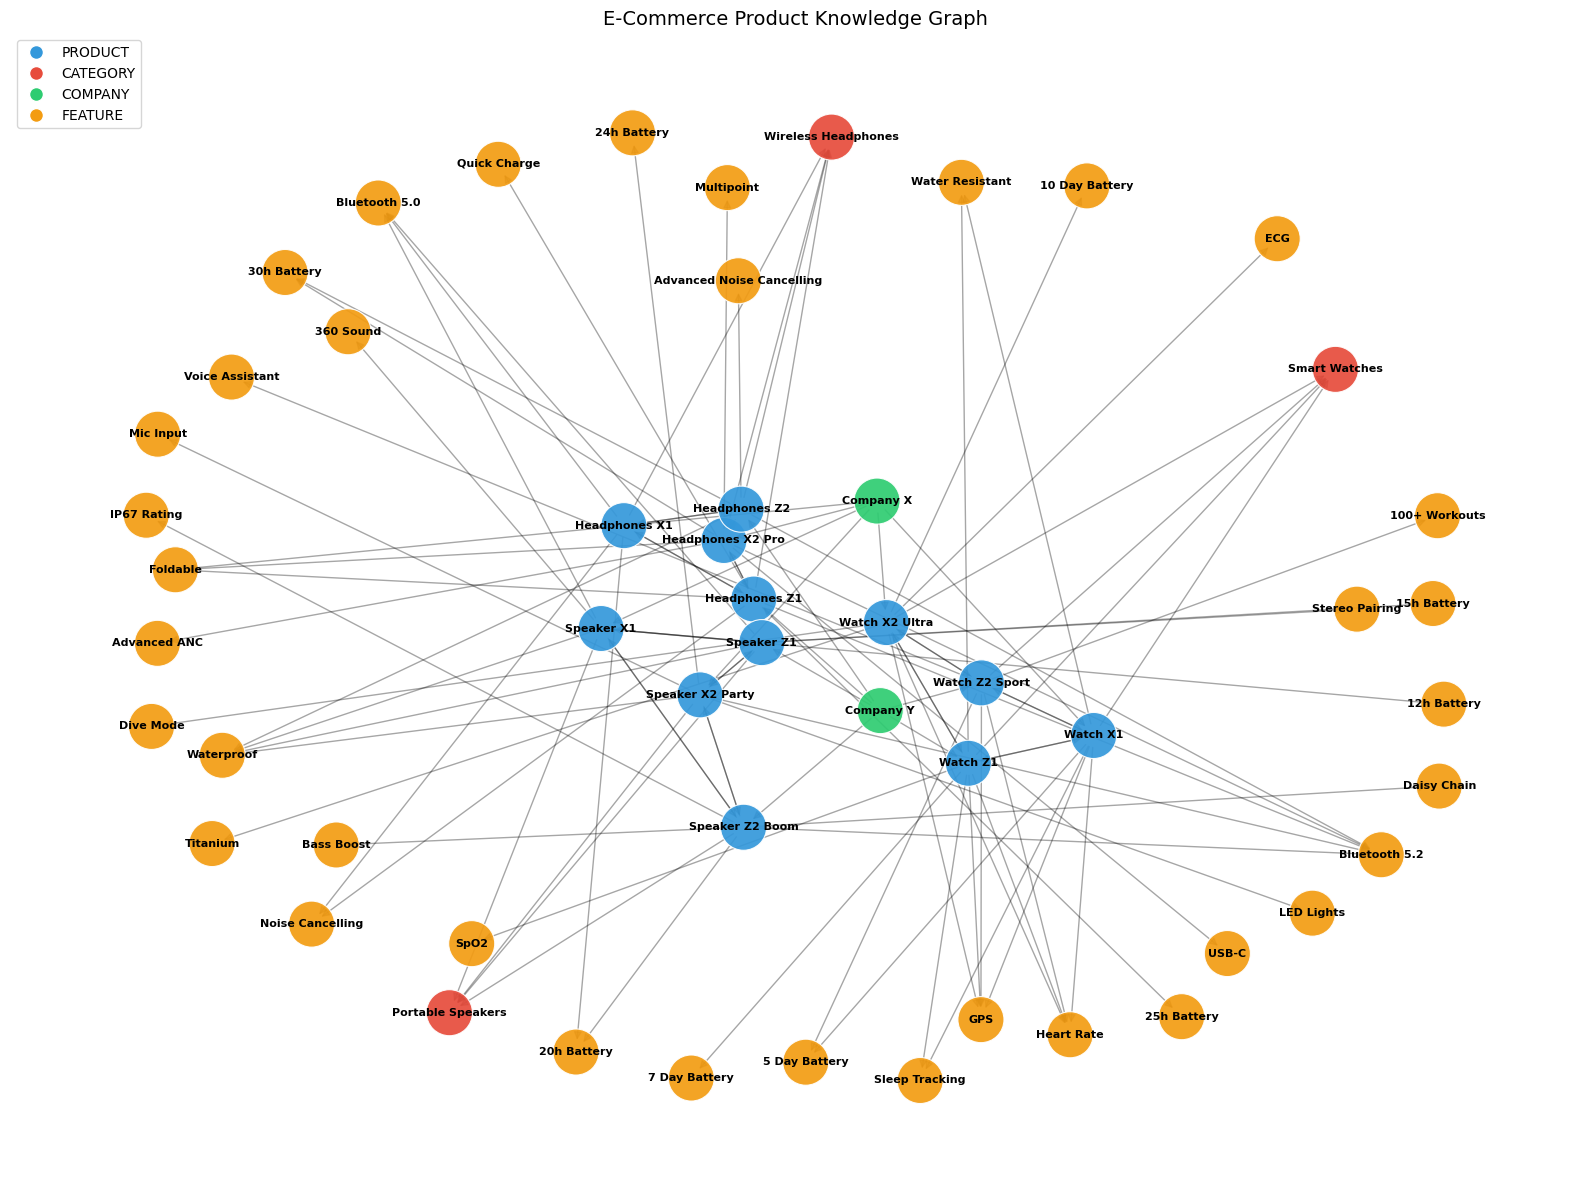

Graph saved to product_knowledge_graph.png


In [44]:
# ============================================================================
# KNOWLEDGE GRAPH VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("Creating Knowledge Graph Visualization...")

# Color map for node types
color_map = {
    'PRODUCT': '#3498db',
    'CATEGORY': '#e74c3c',
    'COMPANY': '#2ecc71',
    'FEATURE': '#f39c12'
}

plt.figure(figsize=(16, 12))

# Build colors and positions
node_colors = [
    color_map.get(product_kg.graph.nodes[n].get('type', 'OTHER'), '#95a5a6')
    for n in product_kg.graph.nodes()
 ]
pos = nx.spring_layout(product_kg.graph, seed=42, k=0.85)

# Draw nodes, edges, and labels
nx.draw_networkx_nodes(
    product_kg.graph,
    pos,
    node_color=node_colors,
    node_size=1100,
    alpha=0.92,
    linewidths=0.8,
    edgecolors='white'
 )
nx.draw_networkx_edges(
    product_kg.graph,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=12,
    width=1.0,
    alpha=0.35
 )

labels = {}
for node, data in product_kg.graph.nodes(data=True):
    if data.get('type') == 'PRODUCT':
        labels[node] = data.get('name', node)
    else:
        labels[node] = node

nx.draw_networkx_labels(
    product_kg.graph,
    pos,
    labels=labels,
    font_size=8,
    font_weight='bold'
 )

# Legend for node types
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=node_type,
           markerfacecolor=color, markersize=10)
    for node_type, color in color_map.items()
 ]
plt.legend(handles=legend_elements, loc='upper left', frameon=True)

plt.title('E-Commerce Product Knowledge Graph', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('product_knowledge_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print("Graph saved to product_knowledge_graph.png")

In [45]:
# ============================================================================
# KNOWLEDGE GRAPH QUERIES
# ============================================================================

print("KNOWLEDGE GRAPH COMPETITIVE ANALYSIS")
print("="*60)

# Query 1 - Find competitors for each Company X product
print("\n[Query 1] Finding Competitors")
print("-" * 40)
for product in products_x[:3]:
    competitors = product_kg.find_competing_products(product['product_id'])
    competitor_names = [
        product_kg.graph.nodes[c].get('name', c)
        for c in competitors
        if c in product_kg.graph
    ]
    print(f"  {product['product_name']} competes with: {len(competitors)} products")
    if competitor_names:
        print(f"    -> {', '.join(competitor_names)}")

# Query 2 - Compare features between products
print("\n[Query 2] Feature Comparison")
print("-" * 40)
p1 = products_x[0]
same_category_competitors = [p for p in products_y if p['category'] == p1['category']]
p2 = same_category_competitors[0] if same_category_competitors else products_y[0]

comparison = product_kg.get_unique_features(p1['product_id'], p2['product_id'])
print(f"  {p1['product_name']} vs {p2['product_name']}")
print(f"  Unique to ours: {comparison['unique_to_ours']}")
print(f"  Unique to competitor: {comparison['unique_to_competitor']}")
print(f"  Common features: {comparison['common']}")

KNOWLEDGE GRAPH COMPETITIVE ANALYSIS

[Query 1] Finding Competitors
----------------------------------------
  Headphones X1 competes with: 3 products
    -> Headphones X2 Pro, Headphones Z1, Headphones Z2
  Headphones X2 Pro competes with: 3 products
    -> Headphones X1, Headphones Z1, Headphones Z2
  Watch X1 competes with: 3 products
    -> Watch X2 Ultra, Watch Z1, Watch Z2 Sport

[Query 2] Feature Comparison
----------------------------------------
  Headphones X1 vs Headphones Z1
  Unique to ours: ['20h Battery', 'Bluetooth 5.0']
  Unique to competitor: ['25h Battery', 'Bluetooth 5.2', 'Quick Charge']
  Common features: ['Foldable', 'Noise Cancelling']


In [46]:
# ============================================================================
# WEEK 6 CHECKPOINT - VALIDATION
# ============================================================================

print("WEEK 6 CHECKPOINT - Verification")
print("="*60)

checks = [
    ("Knowledge graph initialized", product_kg is not None),
    ("Graph has nodes", product_kg.graph.number_of_nodes() > 10),
    ("Graph has edges", product_kg.graph.number_of_edges() > 20),
    ("find_competing_products works", hasattr(product_kg, 'find_competing_products')),
    ("get_unique_features works", hasattr(product_kg, 'get_unique_features')),
]

passed = 0
for check_name, check_result in checks:
    try:
        result = bool(check_result)
    except:
        result = False
    status = "PASS" if result else "FAIL"
    icon = "[OK]" if result else "[X]"
    print(f"  {icon} {check_name}: {status}")
    if result:
        passed += 1

print("\n" + "="*60)
print(f"Week 6 Score: {passed}/{len(checks)} checks passed")
if passed == len(checks):
    print("Week 6 Complete! Proceed to Weeks 7-8.")
else:
    print("Review failed checks before continuing.")

WEEK 6 CHECKPOINT - Verification
  [OK] Knowledge graph initialized: PASS
  [OK] Graph has nodes: PASS
  [OK] Graph has edges: PASS
  [OK] find_competing_products works: PASS
  [OK] get_unique_features works: PASS

Week 6 Score: 5/5 checks passed
Week 6 Complete! Proceed to Weeks 7-8.


In [ ]:
# ============================================================================
# Week 8 : FULL SYSTEM INTEGRATION
# ============================================================================

class EcommerceIntelligenceSystem:
    """
    Production E-Commerce Competitive Intelligence System.

    Integrates:
    - Catalog processor
    - Vector store
    - Multi-agent orchestrator
    - Knowledge graph
    """

    def __init__(self):
        self.processor = processor
        self.vector_store = product_vector_store
        self.orchestrator = ci_orchestrator
        self.knowledge_graph = product_kg
        self.products_x = products_x
        self.products_y = products_y
        self.all_products = self.products_x + self.products_y
        self.default_collection = "products"

    def analyze_category(self, category: str) -> Dict:
        """Run full multi-agent competitive analysis for a category."""
        available_categories = {p["category"] for p in self.all_products}
        if category not in available_categories:
            raise ValueError(
                f"Unknown category '{category}'. Available: {sorted(available_categories)}"
            )

        return self.orchestrator.analyze_category_with_tracing(category)

    def search_products(self, query: str, n_results: int = 5) -> Dict:
        """Run semantic search and return a normalized result payload."""
        if not query or not query.strip():
            raise ValueError("Search query must be a non-empty string.")

        results = self.vector_store.search_with_tracing(
            query=query.strip(),
            collection_name=self.default_collection,
            n_results=n_results,
        )

        normalized_matches = []
        metadatas = results.get("metadatas", [[]])
        documents = results.get("documents", [[]])
        distances = results.get("distances", [[]])
        ids = results.get("ids", [[]])

        first_meta = metadatas[0] if metadatas else []
        first_docs = documents[0] if documents else []
        first_dist = distances[0] if distances else []
        first_ids = ids[0] if ids else []

        for doc_id, meta, doc, dist in zip(first_ids, first_meta, first_docs, first_dist):
            similarity = max(0.0, min(1.0, round(1 - float(dist), 4)))
            normalized_matches.append({
                "id": doc_id,
                "product_name": meta.get("product_name"),
                "company": meta.get("company"),
                "category": meta.get("category"),
                "price": float(meta.get("price", 0)) if str(meta.get("price", "")).strip() else 0.0,
                "availability": meta.get("availability"),
                "similarity": similarity,
                "document": doc,
            })

        return {
            "query": query.strip(),
            "result_count": len(normalized_matches),
            "matches": normalized_matches,
        }

    def get_price_comparison(self, category: str) -> pd.DataFrame:
        """Return a side-by-side price comparison table for a category."""
        category_products = [p for p in self.all_products if p.get("category") == category]
        if not category_products:
            return pd.DataFrame(
                columns=[
                    "company",
                    "product_name",
                    "base_price",
                    "effective_price",
                    "discount_pct",
                    "feature_count",
                    "availability",
                    "sku",
                    "price_gap_vs_category_avg",
                ]
            )

        category_avg = sum(p.get("effective_price", 0) for p in category_products) / len(category_products)

        rows = []
        for product in category_products:
            effective_price = float(product.get("effective_price", 0))
            rows.append({
                "company": product.get("company"),
                "product_name": product.get("product_name"),
                "base_price": float(product.get("base_price", 0)),
                "effective_price": effective_price,
                "discount_pct": int(product.get("discount_pct", 0)),
                "feature_count": int(product.get("feature_count", 0)),
                "availability": product.get("availability"),
                "sku": product.get("sku"),
                "price_gap_vs_category_avg": round(effective_price - category_avg, 2),
            })

        comparison_df = pd.DataFrame(rows)
        comparison_df = comparison_df.sort_values(["company", "effective_price"]).reset_index(drop=True)
        return comparison_df

    def get_status(self) -> Dict:
        """Return high-level system health and component status."""
        return {
            "session_id": SESSION_ID,
            "components": {
                "processor": self.processor is not None,
                "vector_store": self.vector_store is not None,
                "orchestrator": self.orchestrator is not None,
                "knowledge_graph": self.knowledge_graph is not None,
            },
            "catalog": {
                "products_x": len(self.products_x),
                "products_y": len(self.products_y),
                "total_products": len(self.all_products),
                "categories": sorted({p.get("category", "") for p in self.all_products}),
            },
            "vector_store": {
                "collections": sorted(list(self.vector_store.collections.keys())),
            },
            "knowledge_graph": {
                "nodes": self.knowledge_graph.graph.number_of_nodes(),
                "edges": self.knowledge_graph.graph.number_of_edges(),
            },
        }

# Initialize system
ecommerce_system = EcommerceIntelligenceSystem()

print("E-COMMERCE INTELLIGENCE SYSTEM")
print("="*50)
status = ecommerce_system.get_status()
print(f"Session: {status.get('session_id', 'N/A')}")
print(f"Products Indexed: {status['catalog']['total_products']}")
print(f"Vector Collections: {status['vector_store']['collections']}")

E-COMMERCE INTELLIGENCE SYSTEM
Session: contractIQ-20260422-164422
Products Indexed: 12
Vector Collections: ['products']


In [ ]:
# ============================================================================
# GRADIO INTERFACE
# ============================================================================

import gradio as gr

def analyze_category_ui(category: str) -> str:
    """UI function for category analysis."""
    if not category:
        return "Please select a category."

    try:
        result = ecommerce_system.analyze_category(category)
        summary = result.get("summary", {})
        key_findings = summary.get("key_findings", [])
        priority_actions = summary.get("priority_actions", [])
        overall_position = summary.get("overall_position", "UNKNOWN")

        findings_md = "\n".join([f"- {item}" for item in key_findings]) if key_findings else "- No findings returned."
        actions_md = "\n".join([f"- {item}" for item in priority_actions]) if priority_actions else "- No actions returned."

        marketing = result.get("marketing", {})
        marketing_line = ""
        if marketing.get("success") and marketing.get("result"):
            headline = marketing["result"].get("headline", "")
            if headline:
                marketing_line = f"\n\n### Marketing Headline\n{headline}"

        return (
            f"## Category Analysis: {category}\n\n"
            f"**Overall Position:** {overall_position}\n\n"
            f"### Key Findings\n{findings_md}\n\n"
            f"### Priority Actions\n{actions_md}"
            f"{marketing_line}"
        )
    except Exception as exc:
        return f"Error running analysis for '{category}': {exc}"


def search_products_ui(query: str) -> str:
    """UI function for product search."""
    if not query or not query.strip():
        return "Please enter a search query."

    try:
        result = ecommerce_system.search_products(query=query.strip(), n_results=5)
        matches = result.get("matches", [])

        if not matches:
            return f"## Search Results\n\nNo results found for '{query.strip()}'."

        lines = [f"## Search Results for: {result['query']}", ""]
        for idx, match in enumerate(matches, start=1):
            lines.append(
                f"{idx}. **{match.get('product_name', 'Unknown Product')}** "
                f"({match.get('company', 'Unknown Company')})"
            )
            lines.append(f"   - Category: {match.get('category', 'N/A')}")
            lines.append(f"   - Price: ${match.get('price', 0):.2f}")
            lines.append(f"   - Similarity: {match.get('similarity', 0):.4f}")
            lines.append(f"   - Availability: {match.get('availability', 'N/A')}")
            lines.append("")

        return "\n".join(lines).strip()
    except Exception as exc:
        return f"Error running search: {exc}"


def price_comparison_ui(category: str) -> str:
    """UI function for category price comparison."""
    if not category:
        return "Please select a category."

    try:
        comparison_df = ecommerce_system.get_price_comparison(category)
        if comparison_df.empty:
            return f"## Price Comparison: {category}\n\nNo products found for this category."

        display_df = comparison_df.copy()
        display_df["base_price"] = display_df["base_price"].map(lambda x: f"${x:.2f}")
        display_df["effective_price"] = display_df["effective_price"].map(lambda x: f"${x:.2f}")
        display_df["price_gap_vs_category_avg"] = display_df["price_gap_vs_category_avg"].map(lambda x: f"{x:+.2f}")

        return (
            f"## Price Comparison: {category}\n\n"
            f"{display_df.to_markdown(index=False)}"
        )
    except Exception as exc:
        return f"Error generating price comparison for '{category}': {exc}"


print("Gradio UI functions implemented successfully")

Gradio UI functions implemented successfully


In [59]:
# ============================================================================
# TODO: GRADIO APP DEFINITION
# ============================================================================

available_categories = sorted({p.get("category", "") for p in all_products if p.get("category")})
status_data = ecommerce_system.get_status()

with gr.Blocks(title="E-Commerce Intelligence") as demo:
    gr.Markdown("""# E-Commerce Competitive Intelligence System

Multi-agent AI system for competitive analysis with full Langfuse observability.""")

    with gr.Tab("Category Analysis"):
        category_dropdown = gr.Dropdown(
            choices=available_categories,
            label="Select Category",
            value=available_categories[0] if available_categories else None,
        )
        analyze_button = gr.Button("Run Category Analysis", variant="primary")
        category_output = gr.Markdown("Choose a category and click **Run Category Analysis**.")

        analyze_button.click(
            fn=analyze_category_ui,
            inputs=category_dropdown,
            outputs=category_output,
        )

    with gr.Tab("Product Search"):
        search_input = gr.Textbox(
            label="Search Query",
            placeholder="e.g., waterproof speaker for outdoor use",
        )
        search_button = gr.Button("Search Products", variant="primary")
        search_output = gr.Markdown("Enter a query and click **Search Products**.")

        search_button.click(
            fn=search_products_ui,
            inputs=search_input,
            outputs=search_output,
        )
        search_input.submit(
            fn=search_products_ui,
            inputs=search_input,
            outputs=search_output,
        )

    with gr.Tab("Price Comparison"):
        price_category_dropdown = gr.Dropdown(
            choices=available_categories,
            label="Select Category",
            value=available_categories[0] if available_categories else None,
        )
        price_compare_button = gr.Button("Show Price Comparison", variant="primary")
        price_output = gr.Markdown("Choose a category and click **Show Price Comparison**.")

        price_compare_button.click(
            fn=price_comparison_ui,
            inputs=price_category_dropdown,
            outputs=price_output,
        )

    with gr.Tab("System Status"):
        gr.Markdown(
            f"""### System Information

- **Session ID**: {status_data.get('session_id', 'N/A')}
- **Total Products**: {status_data.get('catalog', {}).get('total_products', 0)}
- **Categories**: {', '.join(status_data.get('catalog', {}).get('categories', []))}
- **Vector Collections**: {', '.join(status_data.get('vector_store', {}).get('collections', []))}
- **Knowledge Graph Nodes**: {status_data.get('knowledge_graph', {}).get('nodes', 0)}
- **Knowledge Graph Edges**: {status_data.get('knowledge_graph', {}).get('edges', 0)}
"""
        )

print("Gradio interface defined.")
print("\nTo launch:")
print("  demo.launch(share=True)  # In Colab")
print("  demo.launch()            # Locally")

Gradio interface defined.

To launch:
  demo.launch(share=True)  # In Colab
  demo.launch()            # Locally


In [61]:
# ============================================================================
# LAUNCH GRADIO AND PRINT LINKS
# ============================================================================

launch_kwargs = {
    "share": bool(IN_COLAB),
    "prevent_thread_lock": True,
}

print("Launching Gradio app...")
print(f"Launch config: share={launch_kwargs['share']}")

launch_result = demo.launch(**launch_kwargs)

local_url = None
share_url = None

# Gradio can return different structures across versions.
if isinstance(launch_result, tuple):
    if len(launch_result) > 1:
        local_url = launch_result[1]
    if len(launch_result) > 2:
        share_url = launch_result[2]
else:
    local_url = getattr(launch_result, "local_url", None)
    share_url = getattr(launch_result, "share_url", None)

print("\nGradio launch links:")
print(f"- Local URL: {local_url or 'Not available'}")
print(f"- Share URL: {share_url or 'Not available'}")

Launching Gradio app...
Launch config: share=True
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://346588822b61b91efa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



Gradio launch links:
- Local URL: http://127.0.0.1:7860/
- Share URL: https://346588822b61b91efa.gradio.live


In [60]:
# ============================================================================
# FINAL CHECKPOINT - COMPLETE SYSTEM VERIFICATION
# ============================================================================

print("FINAL CHECKPOINT - Complete System Verification")
print("="*60)

checks = [
    ("Week 1: Langfuse tracing active", langfuse is not None),
    ("Week 1: Traced functions implemented", traced_completion is not None),
    ("Week 2: Product catalogs processed", len(all_products) == 12),
    ("Week 3: Vector store populated", product_vector_store is not None),
    ("Week 4: Price agent ready", price_agent is not None),
    ("Week 4: Catalog agent ready", catalog_agent is not None),
    ("Week 4: Marketing agent ready", marketing_agent is not None),
    ("Week 5: Orchestrator ready", ci_orchestrator is not None),
    ("Week 6: Knowledge graph built", product_kg is not None),
    ("Week 7-8: Full system integrated", ecommerce_system is not None),
    ("Week 7-8: Gradio interface defined", demo is not None),
]

passed = 0
for check_name, check_result in checks:
    try:
        result = bool(check_result)
    except:
        result = False
    status = "PASS" if result else "FAIL"
    icon = "[OK]" if result else "[X]"
    print(f"  {icon} {check_name}: {status}")
    if result:
        passed += 1

print("\n" + "="*60)
print(f"FINAL SCORE: {passed}/{len(checks)} checks passed")
print(f"Grade: {round(passed/len(checks)*100)}%")

if passed == len(checks):
    print("\nCONGRATULATIONS! All 8 weeks completed successfully!")
    print("\nYour E-Commerce Intelligence System includes:")
    print("  - Full Langfuse observability")
    print("  - Semantic product search")
    print("  - Multi-agent competitive analysis")
    print("  - Product knowledge graph")
    print("  - Interactive Gradio UI")
else:
    print("\nSome components need attention. Review the failed checks.")

FINAL CHECKPOINT - Complete System Verification
  [OK] Week 1: Langfuse tracing active: PASS
  [OK] Week 1: Traced functions implemented: PASS
  [OK] Week 2: Product catalogs processed: PASS
  [OK] Week 3: Vector store populated: PASS
  [OK] Week 4: Price agent ready: PASS
  [OK] Week 4: Catalog agent ready: PASS
  [OK] Week 4: Marketing agent ready: PASS
  [OK] Week 5: Orchestrator ready: PASS
  [OK] Week 6: Knowledge graph built: PASS
  [OK] Week 7-8: Full system integrated: PASS
  [OK] Week 7-8: Gradio interface defined: PASS

FINAL SCORE: 11/11 checks passed
Grade: 100%

CONGRATULATIONS! All 8 weeks completed successfully!

Your E-Commerce Intelligence System includes:
  - Full Langfuse observability
  - Semantic product search
  - Multi-agent competitive analysis
  - Product knowledge graph
  - Interactive Gradio UI


In [52]:
# ============================================================================
# FINAL CLEANUP
# ============================================================================

# Flush all traces to Langfuse
if langfuse:
    langfuse.flush()

print("\n" + "="*60)
print("E-COMMERCE INTELLIGENCE SYSTEM - ASSIGNMENT COMPLETE")
print("="*60)
print(f"\nSession: {SESSION_ID}")
print(f"Completed at: {datetime.now().isoformat()}")
print(f"\nAll traces have been flushed to Langfuse.")
print(f"View your traces at: {os.environ.get('LANGFUSE_HOST', 'https://cloud.langfuse.com')}/project")


E-COMMERCE INTELLIGENCE SYSTEM - ASSIGNMENT COMPLETE

Session: contractIQ-20260422-164422
Completed at: 2026-04-22T17:01:37.590471

All traces have been flushed to Langfuse.
View your traces at: https://us.cloud.langfuse.com/project
